#**Exploring Global Matneral Health data:Lifetime Risk of Maternal Death**

#Bethania Robertson | Biomedical Data Science - Capstone Project | 10/20/2025

###This notebook analyzed maternal health data, specifically analyzing Maternal Mortality Ratio (MMR), maternal deaths and liftetime risk (LTR) from 2000 to 2023. It calculates and visualally represents trends globally, regionally and by some specific countries. The analysis aims to reveal patterns and the disparties found in maternal health worldwide.

#####Methods included in this report are but are not limited to computation of percentage change and variability for each variable, correlation analysis to examine the variables relationships and multiple linear regression to assess the combined efffect of maternal deaths on LTR and MMR to better understand the patterns in maternal health


###Raw Data set was utilized from UNICEF Data from *"Trends in maternal mortality 2000-2023"*

Accessing a dataset stored in Google Drive to analysis maternal health. Exploring the data available to use before data manipulation

In [1]:
#Imports for data manipulation
import pandas as pd

#Mounting Data Set into Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#Load the Excel file
file_path = '/content/drive/My Drive/MMRandLTR.xlsx' #link
xls = pd.ExcelFile(file_path)

#Output available sheet names
print("Sheet names:", xls.sheet_names)

Mounted at /content/drive
Sheet names: ['README', 'MMR_country_level', 'MMR_regional_level', 'Maternal deaths_country_level', 'Maternal deaths_regional_level', 'LTR_country_level', 'LTR_regional_level']


#Exploring Maternal Mortality Ratio

##Exploring Global Average MMR Overtime

Exploring Maternal Mortality Ratio - Country Data

In [2]:
#Display Data Structure
mmr_country = xls.parse('MMR_country_level', skiprows=4)
mmr_country.head()

,ISO Code,Country,UNICEF Programme Region,UNICEF Reporting Region,UNICEF Sub-Reporting Region,2000,2001,2002,2003,2004,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AFG,Afghanistan,South Asia,South Asia,South Asia,1372,1311,1263,1201,1166,...,755,741,702,659,629,601,634,660,551,521
1,ALB,Albania,Europe and Central Asia,Europe and Central Asia,Eastern Europe and Central Asia,15,14,14,13,13,...,10,9,8,8,7,7,7,14,8,7
2,DZA,Algeria,Middle East and North Africa,Middle East and North Africa,Middle East and North Africa,123,113,102,101,91,...,80,79,79,77,75,73,97,79,64,62
3,AND,Andorra,Industrialized,Europe and Central Asia,Western Europe,14,14,14,13,12,...,10,10,10,11,11,11,48,18,17,11
4,AGO,Angola,Eastern and Southern Africa,Sub-Saharan Africa,Eastern and Southern Africa,659,629,602,538,499,...,262,249,236,220,208,202,195,211,185,183


Mean MMR by Country-data Worldwide

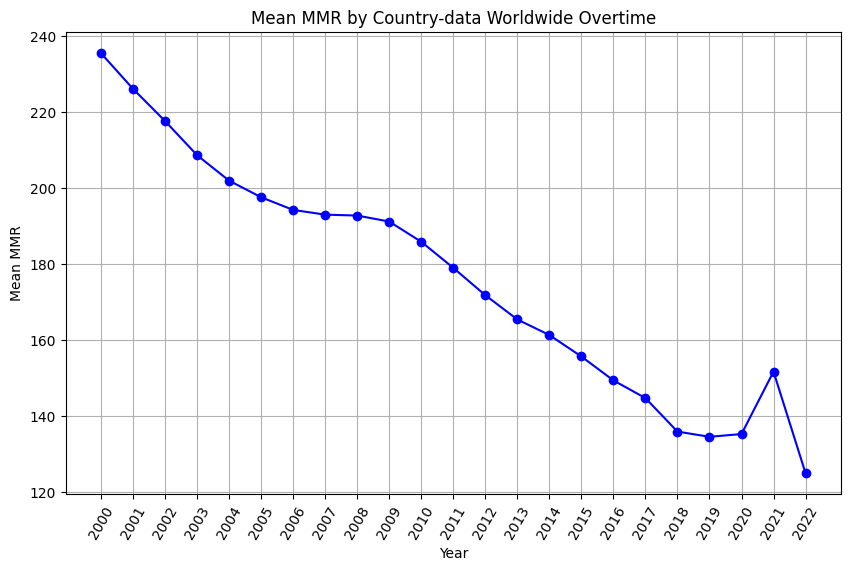

In [3]:
#Imports for plotting and visualization
import matplotlib.pyplot as plt

#Calculating average MMR
years = [str(year) for year in range(2000,2023)] #list of the years
mean_mmr_country = mmr_country[years].mean() #average MMR value for each country

#Plotting
plt.figure(figsize=(10,6))
plt.plot(years, mean_mmr_country, marker='o', linestyle='-', color='b') #Plotting avergae MMR across country data
plt.xticks(rotation=60)
plt.title('Mean MMR by Country-data Worldwide Overtime')
plt.xlabel('Year')
plt.ylabel('Mean MMR')
plt.grid(True)
plt.show()

##Exploring Country Level MMR Analysis Overtime

Maternal Mortality Ratio (MMR) Trends for Selected Countries

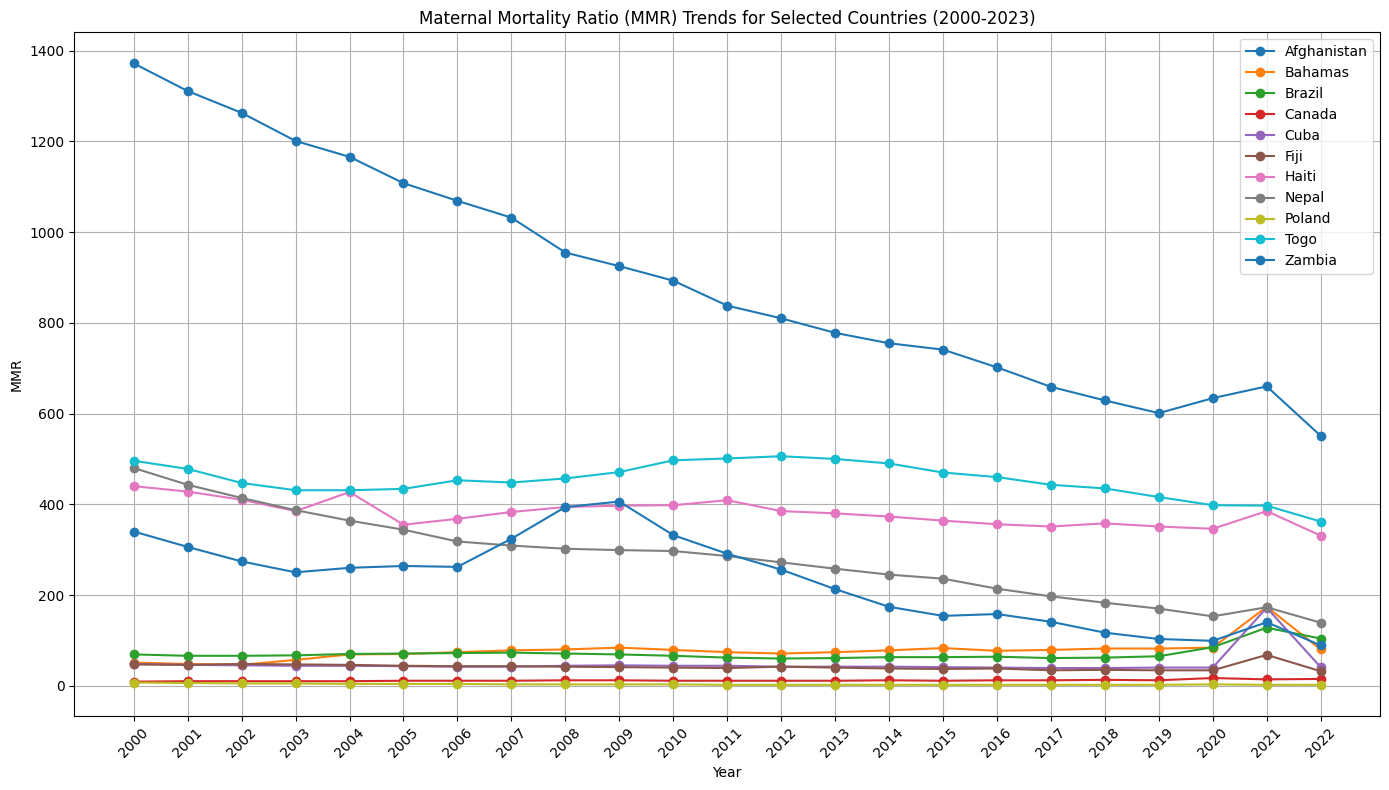

In [4]:
#List of countries
countries_to_plot = ['Afghanistan', 'Bahamas', 'Brazil','Canada', 'Cuba', 'Fiji', 'Haiti','Nepal', 'Poland', 'Togo', 'Zambia']

#PLotting
plt.figure(figsize=(14, 8))

#Lopping through each country for their MMR
for country in countries_to_plot:
    country_data = mmr_country[mmr_country['Country'] == country][years].T #row for country and the column year
    plt.plot(years, country_data.values.flatten(), marker='o', label=country) #countries MMR overtime
plt.title('Maternal Mortality Ratio (MMR) Trends for Selected Countries (2000-2023)')
plt.xlabel('Year')
plt.ylabel('MMR')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##Exploring Regional MMR Analysis Overtime

Exploring Maternal Mortality Ratio - Region Data

In [5]:
mmr_region = xls.parse('MMR_regional_level', skiprows=5)
mmr_region.head()

,UNICEF,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,East Asia and Pacific,119.0,117.0,112.0,108.0,106.0,101.0,99.0,95.0,92.0,...,71.0,70.0,66.0,62.0,64.0,63.0,72.0,94.0,72.0,66.0
1,Europe and Central Asia,25.0,24.0,24.0,23.0,22.0,21.0,19.0,19.0,18.0,...,14.0,14.0,13.0,13.0,12.0,12.0,16.0,18.0,14.0,11.0
2,Eastern Europe and Central Asia,41.0,39.0,37.0,36.0,34.0,33.0,30.0,28.0,27.0,...,20.0,19.0,18.0,18.0,17.0,17.0,22.0,26.0,19.0,16.0
3,Western Europe,9.0,9.0,9.0,8.0,8.0,8.0,8.0,7.0,7.0,...,7.0,7.0,7.0,6.0,6.0,6.0,8.0,8.0,8.0,6.0
4,Latin America and Caribbean,92.0,90.0,88.0,87.0,88.0,85.0,85.0,84.0,84.0,...,74.0,74.0,75.0,76.0,77.0,76.0,94.0,140.0,93.0,77.0


Average Maternal Mortality Ratio (MMR) by Region

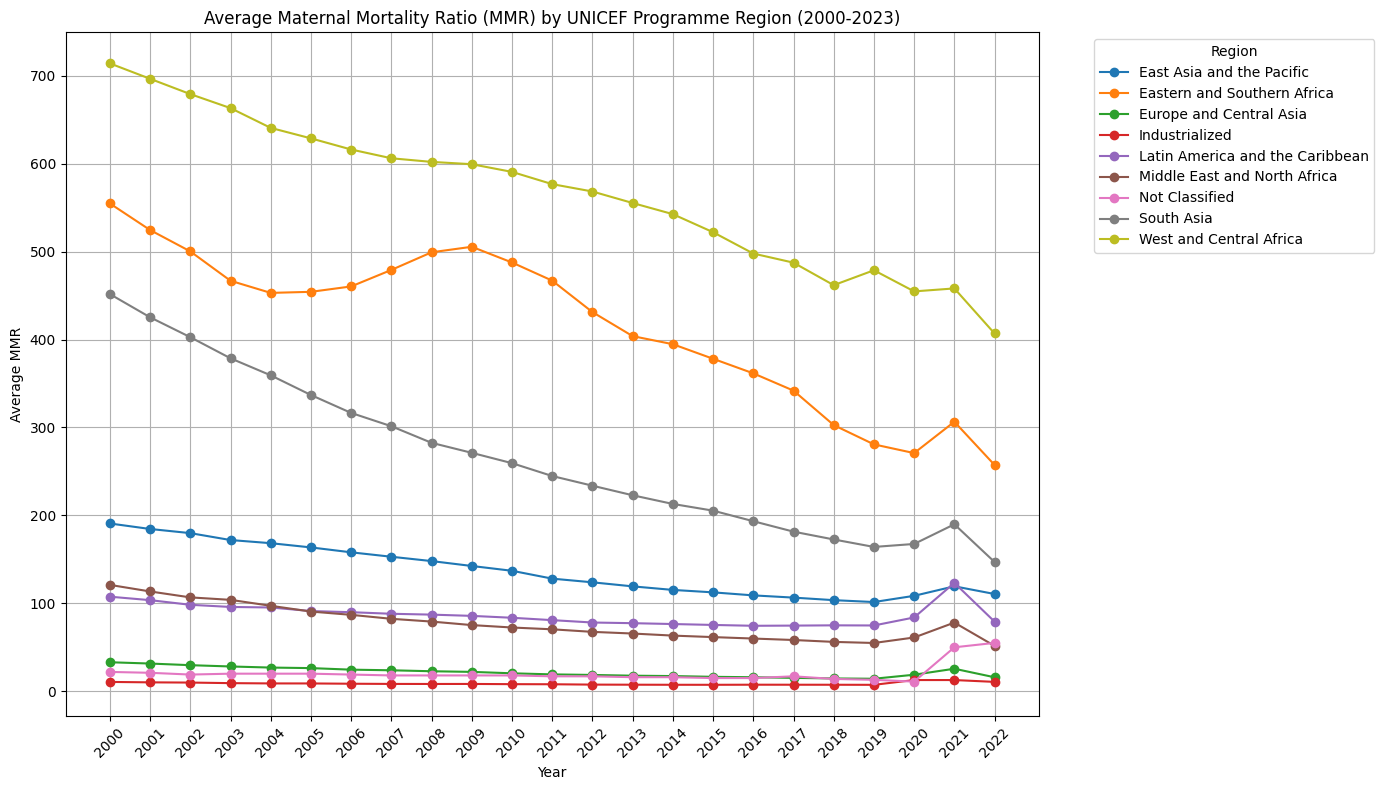

In [6]:
#List of years
years = [str(year) for year in range(2000, 2023)]

#Grouping each year and calculating mean MMR for each
region_mmr = mmr_country.groupby('UNICEF Programme Region')[years].mean()

#PLotting
plt.figure(figsize=(14, 8))
for region in region_mmr.index: #Looping through the different countries in each region
    plt.plot(years, region_mmr.loc[region], marker='o', label=region)
plt.title('Average Maternal Mortality Ratio (MMR) by UNICEF Programme Region (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Average MMR')
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Specific Regions MMR Trends overlayed with Respective Countries

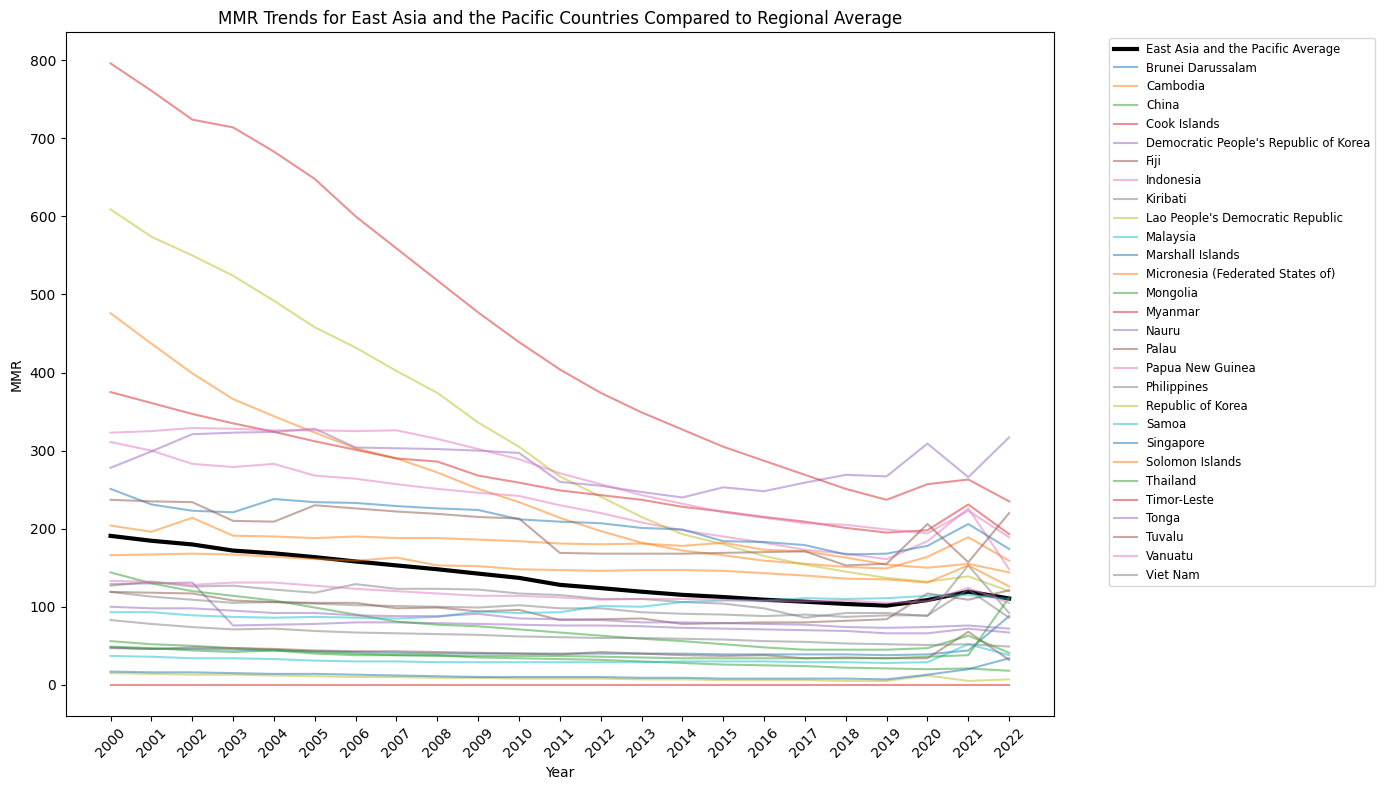

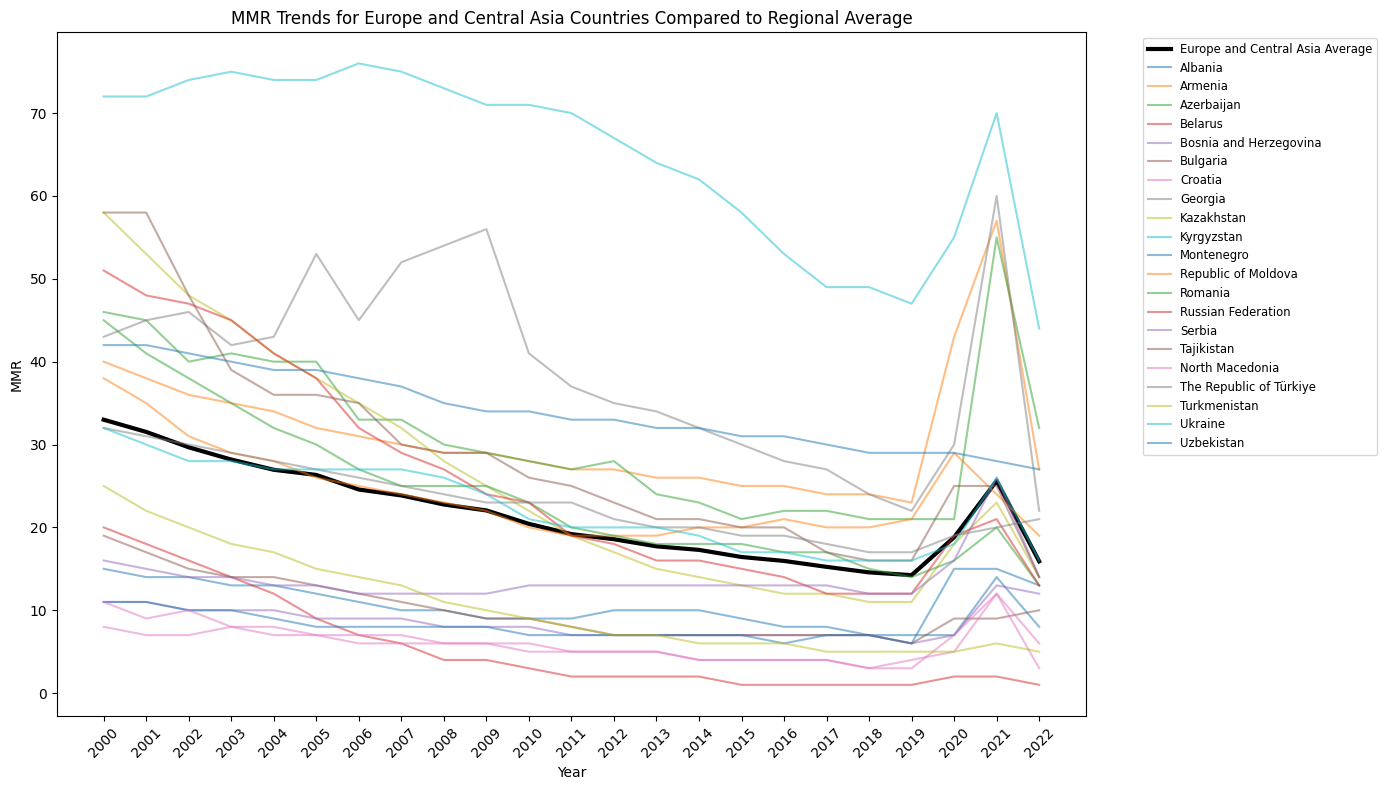

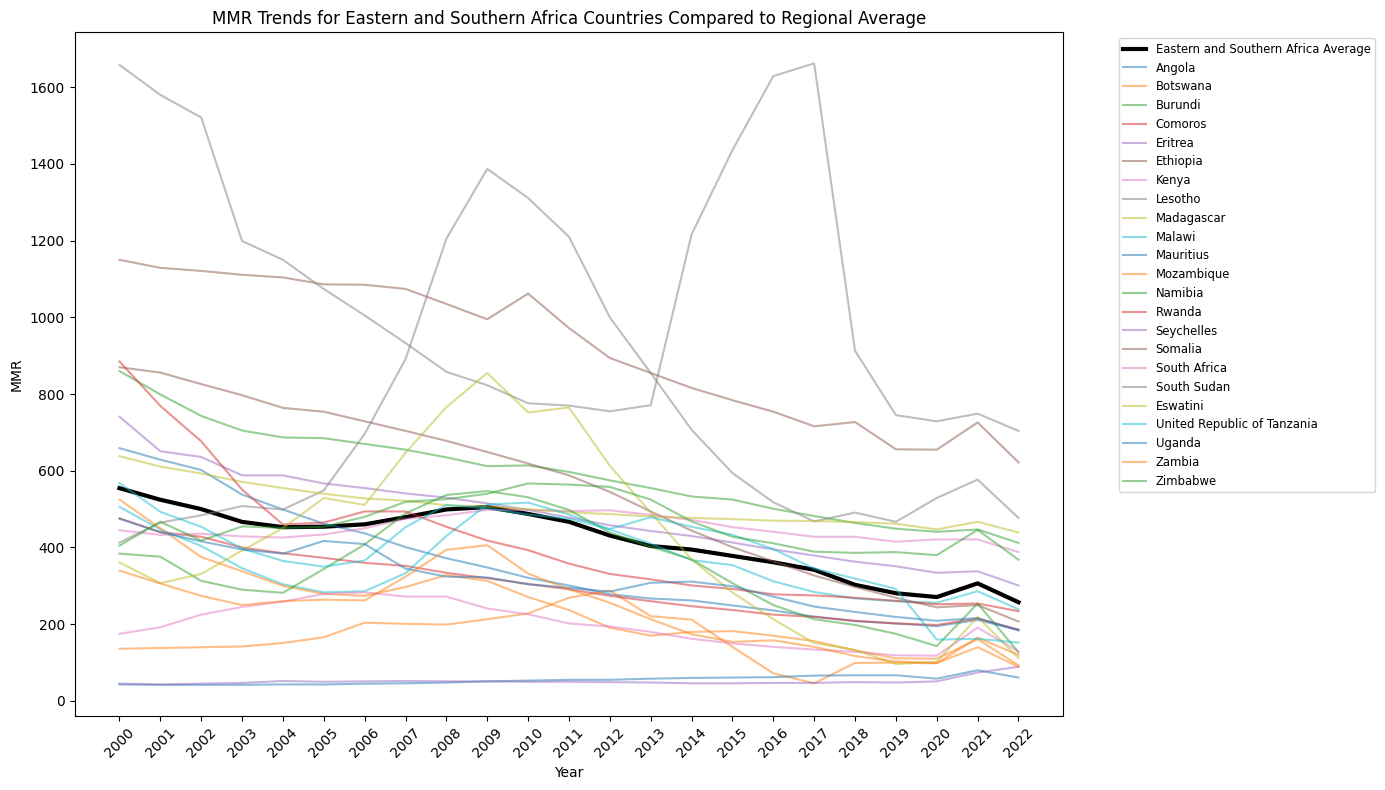

In [7]:
'''
East Asia and the Pacific
'''

#specific region
region = 'East Asia and the Pacific'

#visualizing specific countries from that region
countries_in_region = mmr_country[mmr_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_mmr.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = mmr_country[mmr_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'MMR Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('MMR')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

'''
Europe and Central Asia
'''

#specific region
region = 'Europe and Central Asia'

#visualizing specific countries from that region
countries_in_region = mmr_country[mmr_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_mmr.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = mmr_country[mmr_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'MMR Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('MMR')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

'''
Eastern and Southern Africa
'''
#specific region
region = 'Eastern and Southern Africa'

#visualizing specific countries from that region
countries_in_region = mmr_country[mmr_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_mmr.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = mmr_country[mmr_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'MMR Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('MMR')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

Linear Regression on Regional Average MMR to Visualize Annual trends

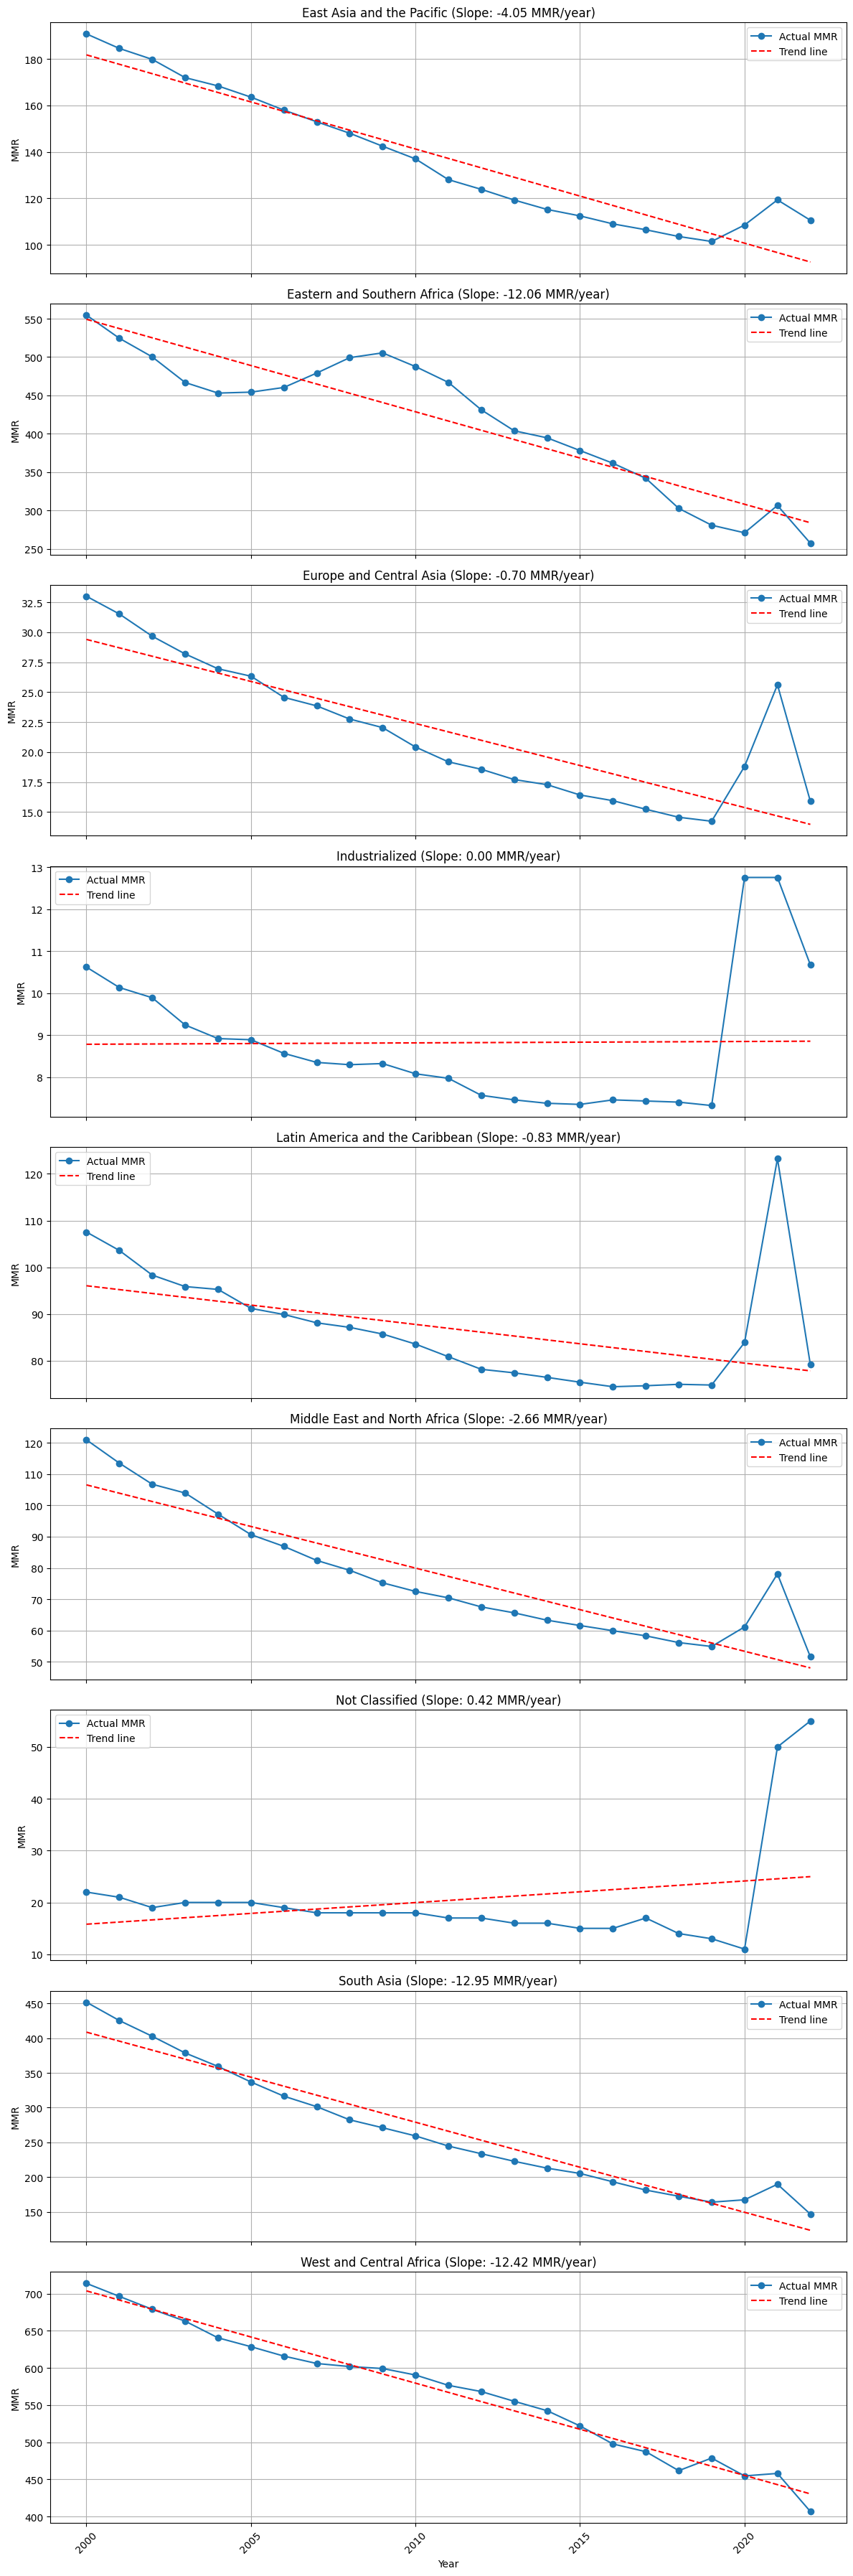

Yearly MMR trends by region (negative slope = decrease in MMR):
                                 MMR Yearly Slope
South Asia                             -12.950222
West and Central Africa                -12.423460
Eastern and Southern Africa            -12.056797
East Asia and the Pacific               -4.051278
Middle East and North Africa            -2.659140
Latin America and the Caribbean         -0.827554
Europe and Central Asia                 -0.701016
Industrialized                           0.003312
Not Classified                           0.416996


In [8]:
#Imports
from sklearn.linear_model import LinearRegression
import numpy as np

#Years
X = np.array([int(year) for year in years]).reshape(-1, 1)

#Storage for Slope (rate of change) per region
region_slopes = {}

#Plotting
num_regions = len(region_mmr.index) #setting up one grid per region
fig, axs = plt.subplots(nrows=num_regions, ncols=1, figsize=(12, 4*num_regions), sharex=True)

#Keeps Consistent Looping
if num_regions == 1:  #one region? axis will not be an array
    axs = [axs]

#Looping over region to fit linear regression
for i, region in enumerate(region_mmr.index):
    y_vals = region_mmr.loc[region, years].values.flatten() #flattening MMR values for current region
    mask = ~np.isnan(y_vals) #filters out NaN values
    X_clean = X[mask] #filtered years with available data
    y_clean = y_vals[mask] #data without NaNs

    #Regression with enough data
    if len(y_clean) > 1:
        model = LinearRegression()
        model.fit(X_clean, y_clean) #fitting model
        slope = model.coef_[0] #extracting slope
        region_slopes[region] = slope #slope storage

        #Plotting MMR Values Overtime
        axs[i].plot([int(y) for y in years], y_vals, marker='o', label='Actual MMR')#Individual Data points
        axs[i].plot([int(y) for y in years], model.predict(X), linestyle='--', color='red', label='Trend line')#Regression line
        axs[i].set_title(f"{region} (Slope: {slope:.2f} MMR/year)")
        axs[i].set_ylabel('MMR')
        axs[i].grid(True)
        axs[i].legend()

plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Slope to DataFrame
region_slopes_df = pd.DataFrame.from_dict(region_slopes, orient='index', columns=['MMR Yearly Slope'])
region_slopes_df = region_slopes_df.sort_values('MMR Yearly Slope')

#Outputs
print("Yearly MMR trends by region (negative slope = decrease in MMR):")
print(region_slopes_df)


Percentage and Variability within Regional Data - MMR

Percentage change in average MMR by region (2000 to 2023):
UNICEF Programme Region
South Asia                         -67.45
Middle East and North Africa       -57.34
Eastern and Southern Africa        -53.61
Europe and Central Asia            -51.80
West and Central Africa            -43.02
East Asia and the Pacific          -42.03
Latin America and the Caribbean    -26.37
Industrialized                       0.51
Not Classified                     150.00
dtype: float64


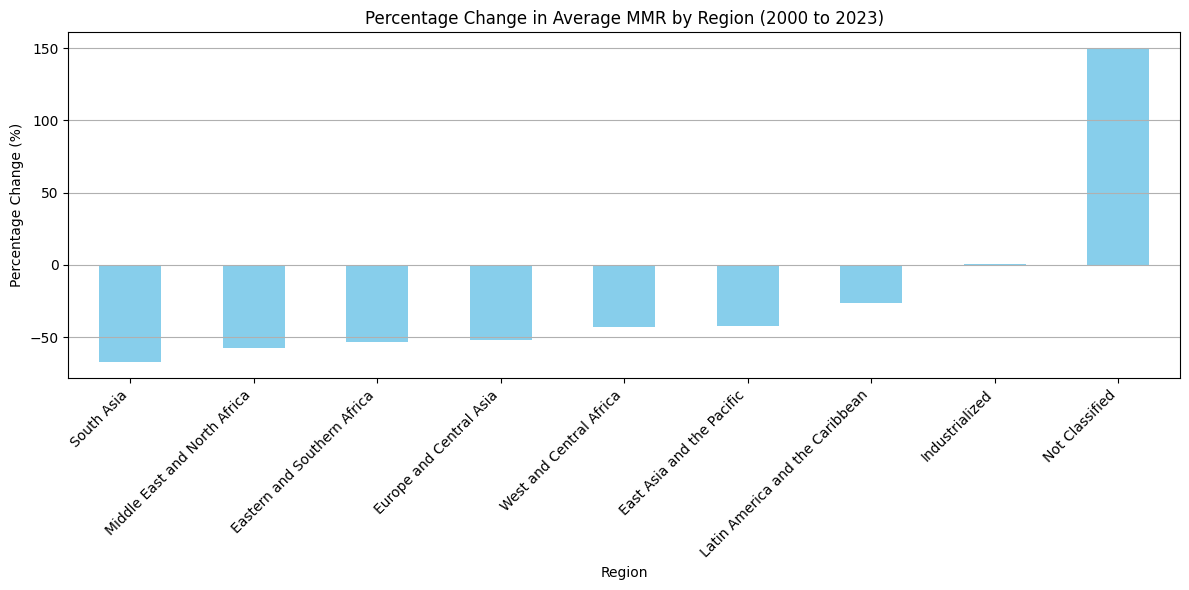


Average standard deviation of MMR within regions (variability across countries):
Industrialized                       5.84
Europe and Central Asia             15.07
Latin America and the Caribbean     70.83
Middle East and North Africa       101.23
East Asia and the Pacific          115.68
Eastern and Southern Africa        267.63
South Asia                         274.78
West and Central Africa            318.25
Not Classified                        NaN
dtype: float64


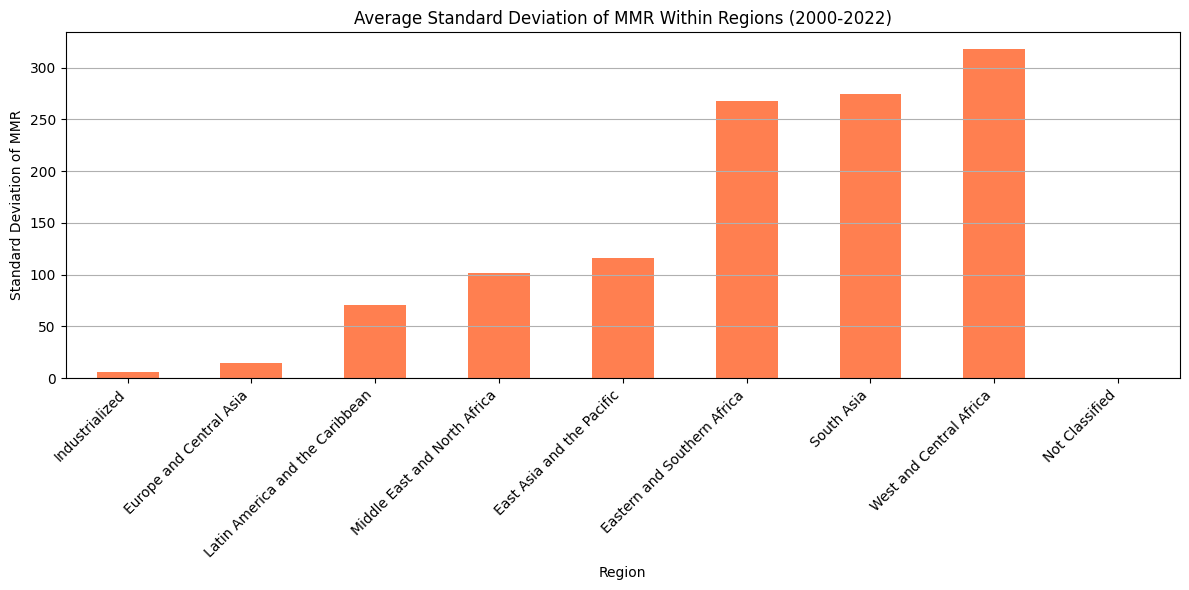

In [9]:
#Defining Variables
start_year = '2000'
end_year = '2022'

#Calculating percentage change - MMR
percent_change = ((region_mmr[end_year] - region_mmr[start_year]) / region_mmr[start_year]) * 100
percent_change = percent_change.round(2)

#Ooutputs of percentage change
print("Percentage change in average MMR by region (2000 to 2023):")
print(percent_change.sort_values())

#Plotting
plt.figure(figsize=(12, 6))
percent_change.sort_values().plot(kind='bar', color='skyblue') #percentage change
plt.title('Percentage Change in Average MMR by Region (2000 to 2023)')
plt.ylabel('Percentage Change (%)')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#Calculating Variability - MMR
regions = mmr_country['UNICEF Programme Region'].unique()
variability_dict = {}

#Looping through regions
for region in regions:
    region_countries = mmr_country[mmr_country['UNICEF Programme Region'] == region] #specific countries
    std_devs = region_countries[years].std(axis=0) #STD
    avg_std_dev = std_devs.mean() #Average STD
    variability_dict[region] = avg_std_dev #Varibaility of Avergae STD
variability_df = pd.Series(variability_dict).round(2).sort_values()

#Outputs of Varibaility
print("\nAverage standard deviation of MMR within regions (variability across countries):")
print(variability_df)

#Plotting
plt.figure(figsize=(12, 6))
variability_df.plot(kind='bar', color='coral')
plt.title('Average Standard Deviation of MMR Within Regions (2000-2022)') #variability
plt.ylabel('Standard Deviation of MMR')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#Exploring Maternal Deaths

Exploring Maternal Death - Country Data

In [10]:
#Display Data Structure
maternal_deaths_country = pd.read_excel(file_path, sheet_name='Maternal deaths_country_level', skiprows=4)
maternal_deaths_country.head()

,ISO Code,Country,UNICEF Programme Region,UNICEF Reporting Region,UNICEF Sub-Reporting Region,2000,2001,2002,2003,2004,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AFG,Afghanistan,South Asia,South Asia,South Asia,14000,13000,13000,13000,13000,...,9800,9900,9400,9000,8700,8500,9100,9600,8100,7600
1,ALB,Albania,Europe and Central Asia,Europe and Central Asia,Eastern Europe and Central Asia,9,8,7,7,6,...,4,3,3,3,2,2,2,4,2,2
2,DZA,Algeria,Middle East and North Africa,Middle East and North Africa,Middle East and North Africa,740,690,620,640,600,...,820,820,820,810,770,740,960,760,600,570
3,AND,Andorra,Industrialized,Europe and Central Asia,Western Europe,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AGO,Angola,Eastern and Southern Africa,Sub-Saharan Africa,Eastern and Southern Africa,5000,4900,4900,4500,4300,...,3000,2900,2800,2700,2600,2600,2500,2800,2500,2500


Global Matneral Deaths Overtime

&

Regional Maternal Deaths Overtime

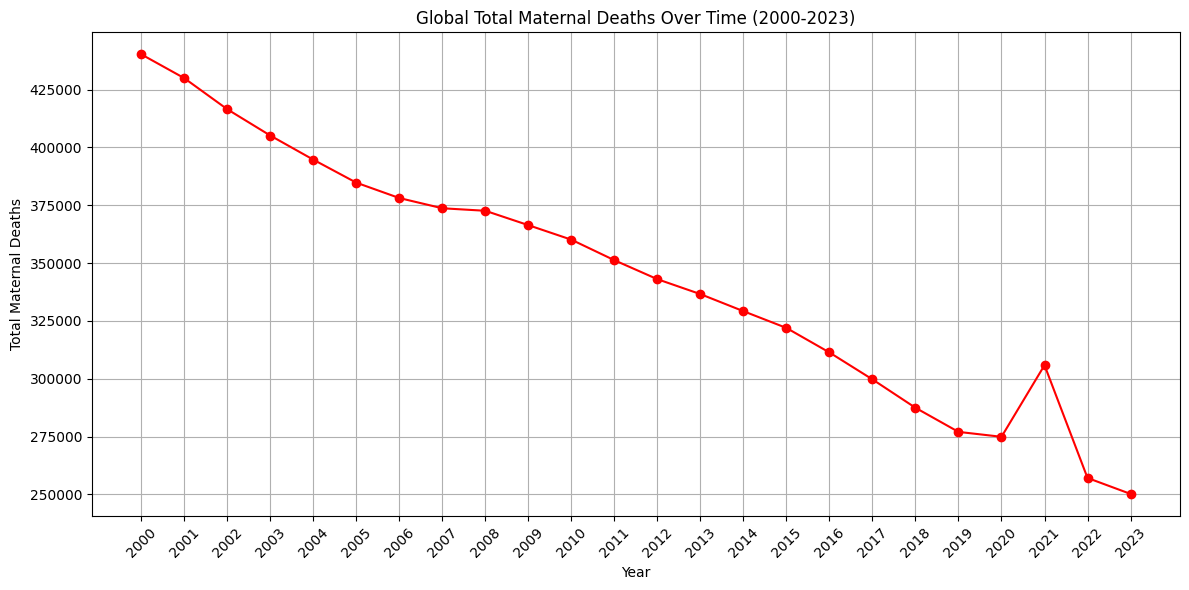

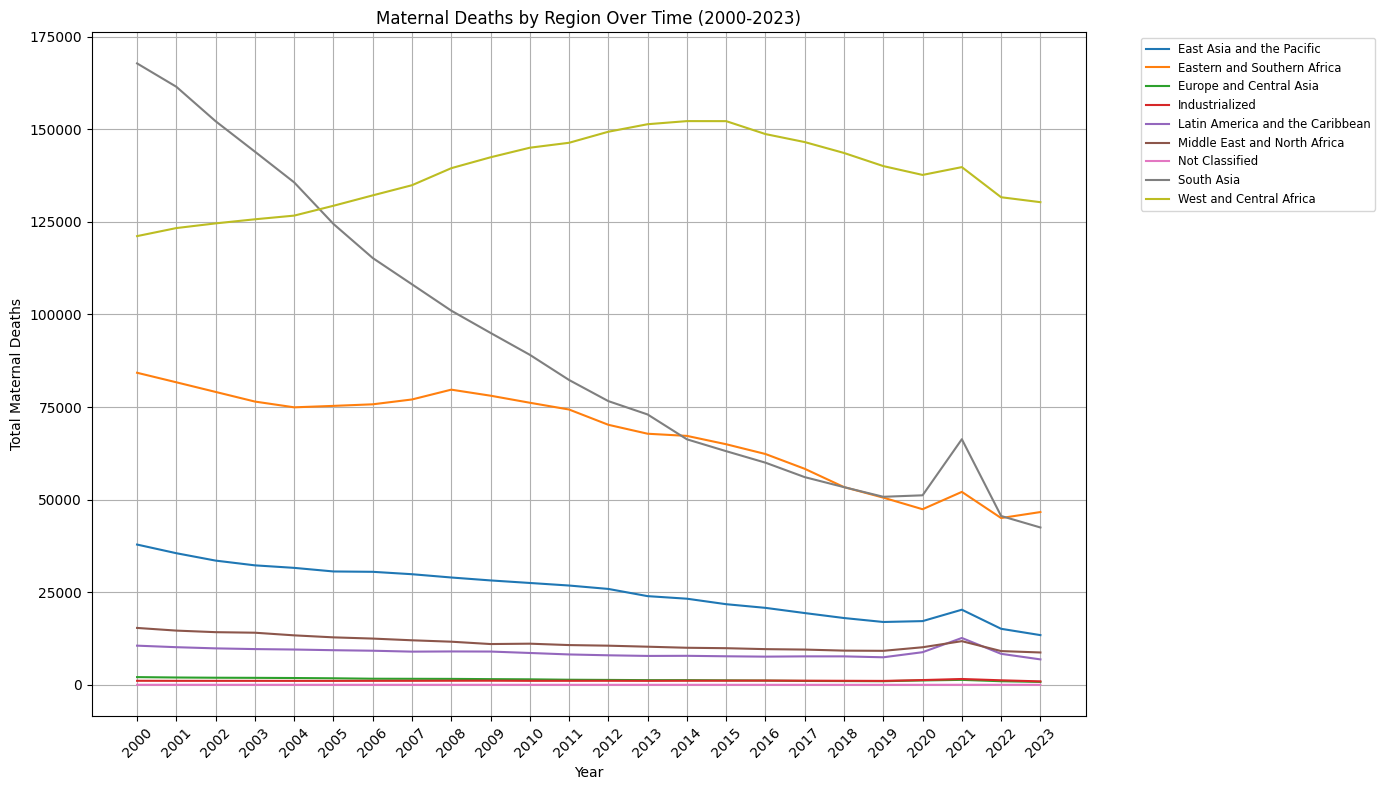

In [11]:
#Years
years = [str(year) for year in range(2000, 2024)]

#Turn NaNs to 0
maternal_deaths_country[years] = maternal_deaths_country[years].fillna(0)

#Calculating global and regions total maternal deaths per year
global_maternal_deaths = maternal_deaths_country[years].sum() #global
region_maternal_deaths = maternal_deaths_country.groupby('UNICEF Programme Region')[years].sum() #regional

#Plotting - Global
plt.figure(figsize=(12, 6))
plt.plot(years, global_maternal_deaths.values, marker='o', color='red') #global average
plt.title('Global Total Maternal Deaths Over Time (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Total Maternal Deaths')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#Plotting - Regional
plt.figure(figsize=(14, 8))
for region in region_maternal_deaths.index: #Looping over each region
    plt.plot(years, region_maternal_deaths.loc[region], label=region)
plt.title('Maternal Deaths by Region Over Time (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Total Maternal Deaths')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


Specific Regions Maternal Death Trends overlayed with Respective Countries

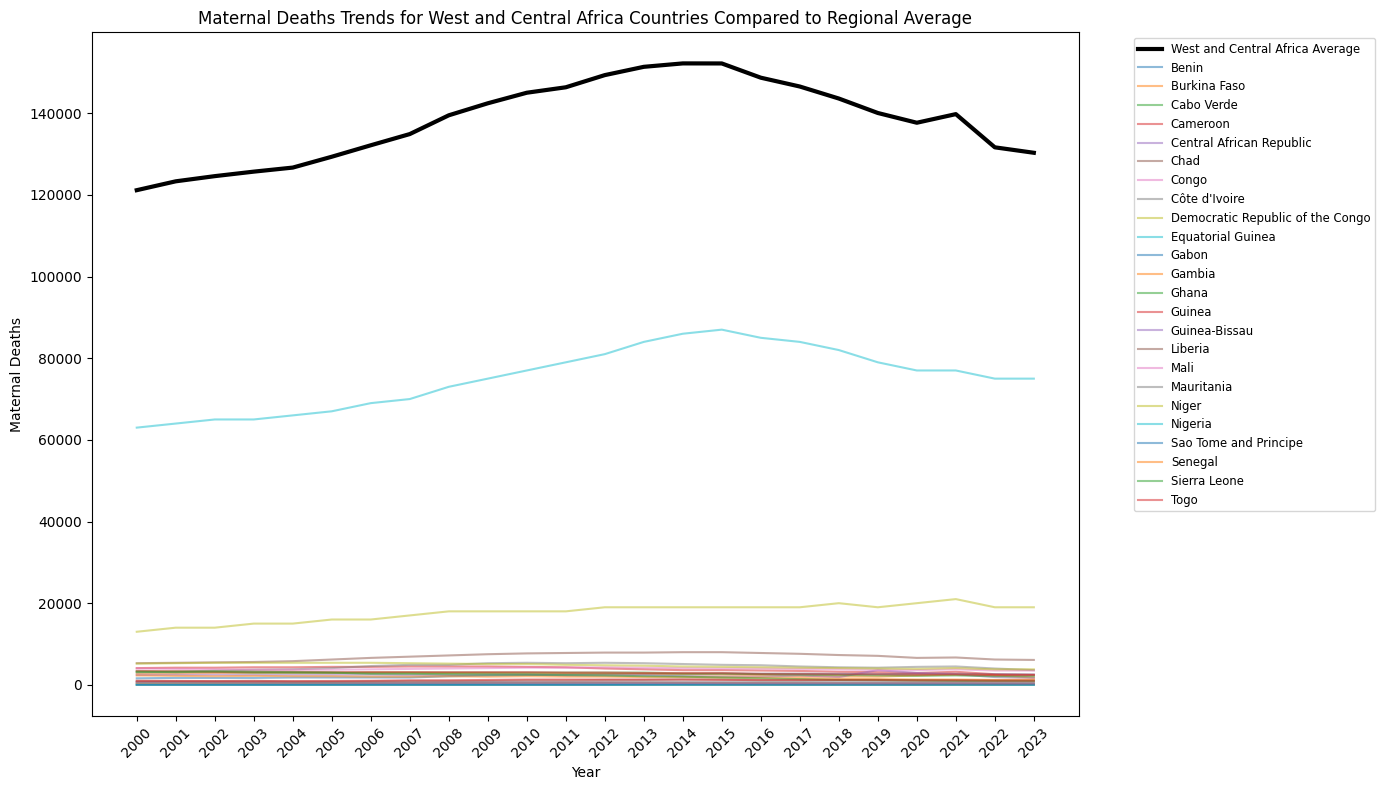

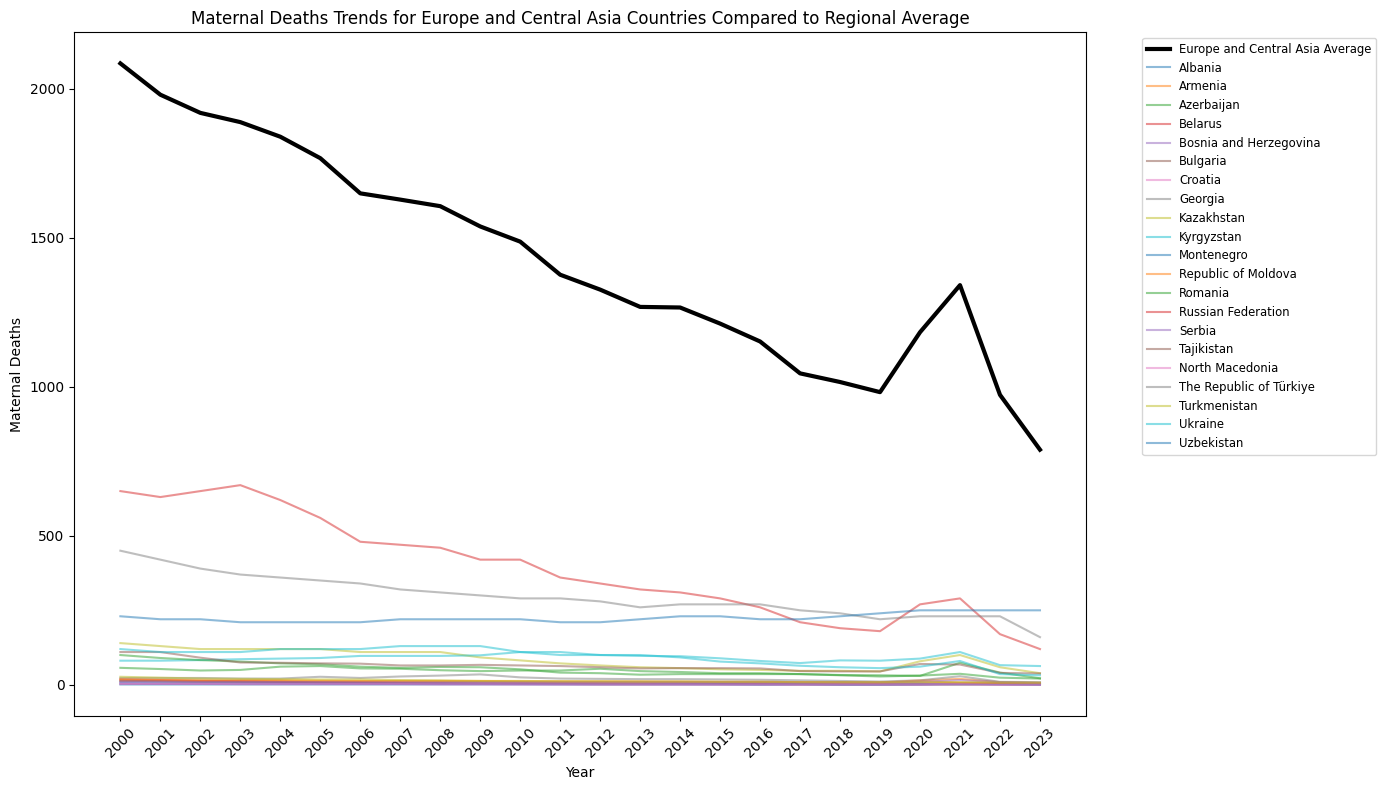

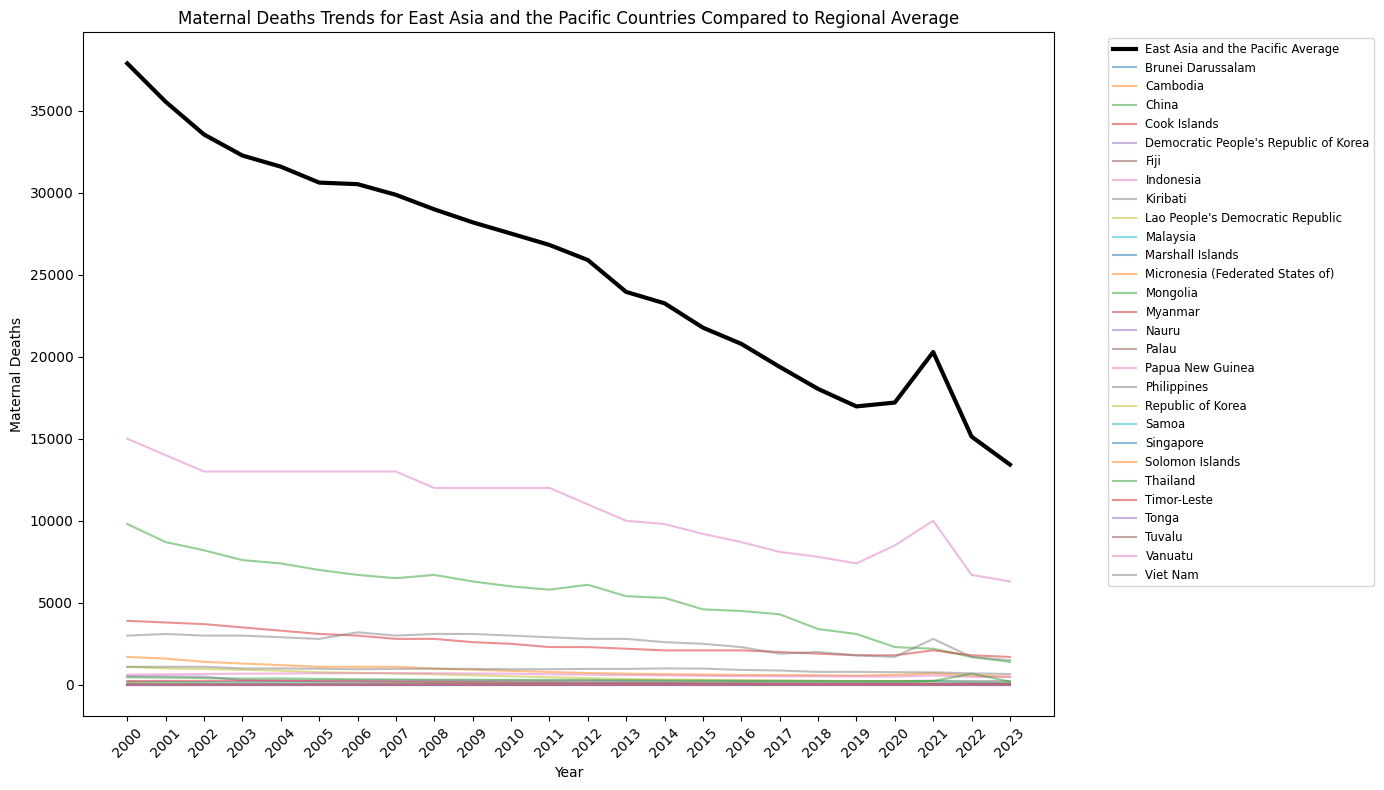

In [12]:
'''
Western and Central Africa
'''

#region
region = 'West and Central Africa'

#visualizing specific countries from that region
countries_in_region = maternal_deaths_country[maternal_deaths_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_maternal_deaths.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = maternal_deaths_country[maternal_deaths_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'Maternal Deaths Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('Maternal Deaths')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

'''
Europe and Central Asia
'''
#region
region = 'Europe and Central Asia'

#visualizing specific countries from that region
countries_in_region = maternal_deaths_country[maternal_deaths_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_maternal_deaths.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = maternal_deaths_country[maternal_deaths_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'Maternal Deaths Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('Maternal Deaths')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()
'''
East Asia and the Pacific
'''
#region
region = 'East Asia and the Pacific'

#visualizing specific countries from that region
countries_in_region = maternal_deaths_country[maternal_deaths_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_maternal_deaths.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = maternal_deaths_country[maternal_deaths_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'Maternal Deaths Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('Maternal Deaths')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()



Linear Regression on Regional Maternal Death to Visualize Annual trends

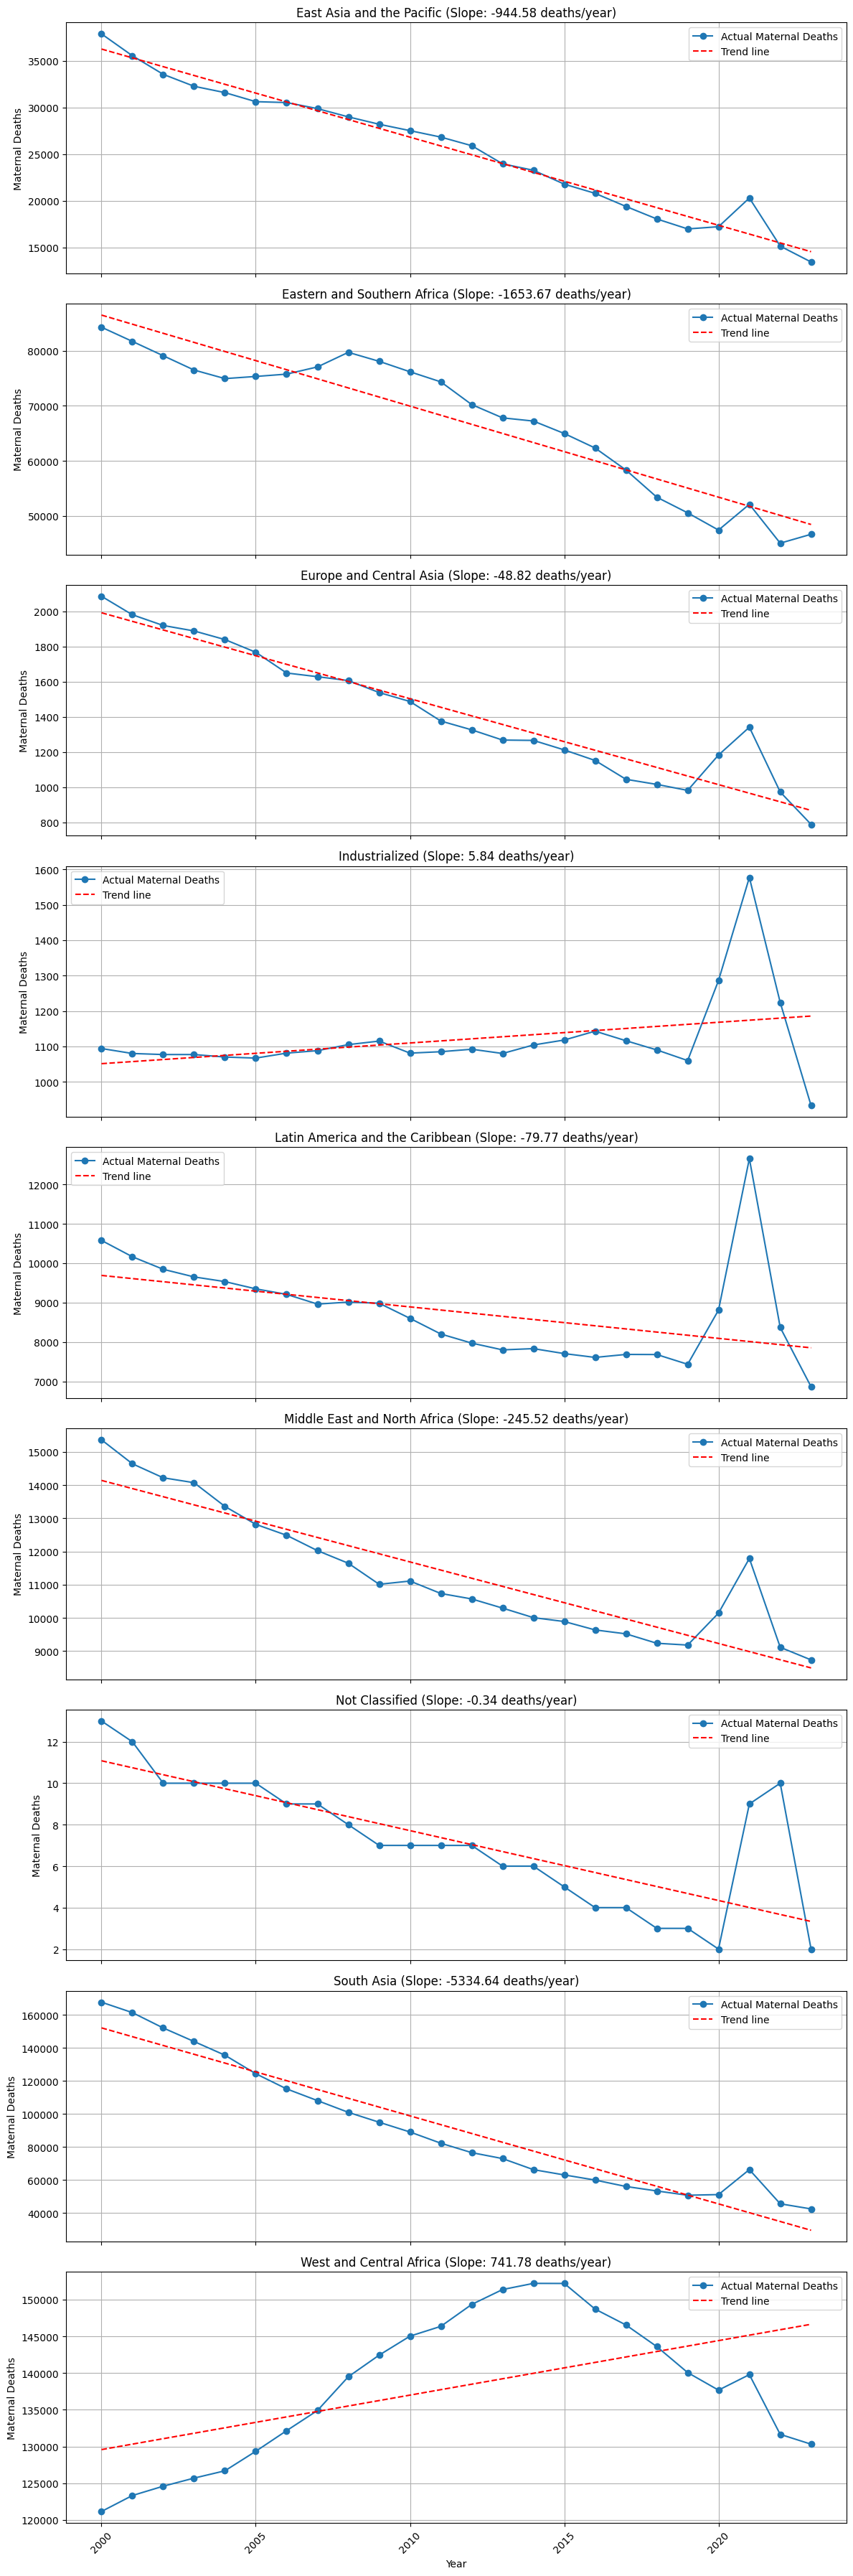

Yearly maternal death trends by region (negative slope = decrease in deaths):
                                 Maternal Deaths Yearly Slope
South Asia                                       -5334.641739
Eastern and Southern Africa                      -1653.671304
East Asia and the Pacific                         -944.578261
Middle East and North Africa                      -245.521739
Latin America and the Caribbean                    -79.769565
Europe and Central Asia                            -48.823043
Not Classified                                      -0.336957
Industrialized                                       5.844783
West and Central Africa                            741.778261


In [13]:
#Years
X = np.array([int(year) for year in years]).reshape(-1, 1)

#Storage for Slope(rate of change) by regions
region_slopes = {}

#One plot per region
num_regions = len(region_maternal_deaths.index)
fig, axs = plt.subplots(nrows=num_regions, ncols=1, figsize=(12, 4*num_regions), sharex=True)

#Ensurings if there is only 1 regions that the axis is not an array
if num_regions == 1:
    axs = [axs]

for i, region in enumerate(region_maternal_deaths.index): #looping through each region
    y_vals_raw = region_maternal_deaths.loc[region, years].values.flatten() #extracting maternal death values
    y_vals = pd.to_numeric(y_vals_raw, errors='coerce')

    #Masking non-Nan values
    mask = ~np.isnan(y_vals)
    X_clean = X[mask]
    y_clean = y_vals[mask]

    if len(y_clean) > 1:
        model = LinearRegression() #linear regression
        model.fit(X_clean, y_clean) #fitting the model
        slope = model.coef_[0]
        region_slopes[region] = slope

#Plotting
        axs[i].plot([int(y) for y in years], y_vals, marker='o', label='Actual Maternal Deaths') #plotting raw data points
        axs[i].plot([int(y) for y in years], model.predict(X), linestyle='--', color='red', label='Trend line') #plotting regression line

        axs[i].set_title(f"{region} (Slope: {slope:.2f} deaths/year)")
        axs[i].set_ylabel('Maternal Deaths')
        axs[i].grid(True)
        axs[i].legend()

plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Adding the slopes from the storage to DF
region_slopes_df = pd.DataFrame.from_dict(region_slopes, orient='index', columns=['Maternal Deaths Yearly Slope'])
region_slopes_df = region_slopes_df.sort_values('Maternal Deaths Yearly Slope')

#Outputs
print("Yearly maternal death trends by region (negative slope = decrease in deaths):")
print(region_slopes_df)


Percentage and Variability within Regional Data - Maternal Death

Percentage change in average maternal deaths by region (2000 to 2023):
UNICEF Programme Region
Not Classified                    -84.62
South Asia                        -74.68
East Asia and the Pacific         -64.56
Europe and Central Asia           -62.16
Eastern and Southern Africa       -44.63
Middle East and North Africa      -43.14
Latin America and the Caribbean   -35.06
Industrialized                    -14.72
West and Central Africa             7.56
dtype: float64


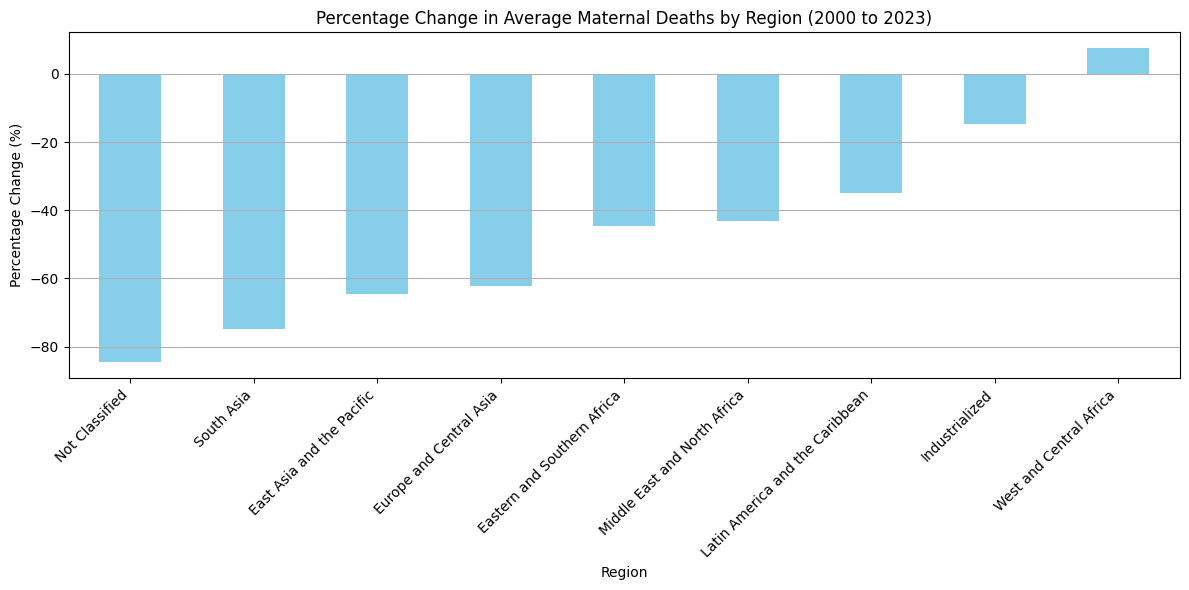


Average standard deviation of maternal deaths within regions (variability across countries):
Industrialized                       103.91
Europe and Central Asia              108.95
Latin America and the Caribbean      454.88
Middle East and North Africa        1195.59
East Asia and the Pacific           2277.65
Eastern and Southern Africa         3986.80
West and Central Africa            15241.12
South Asia                         17827.83
Not Classified                          NaN
dtype: float64


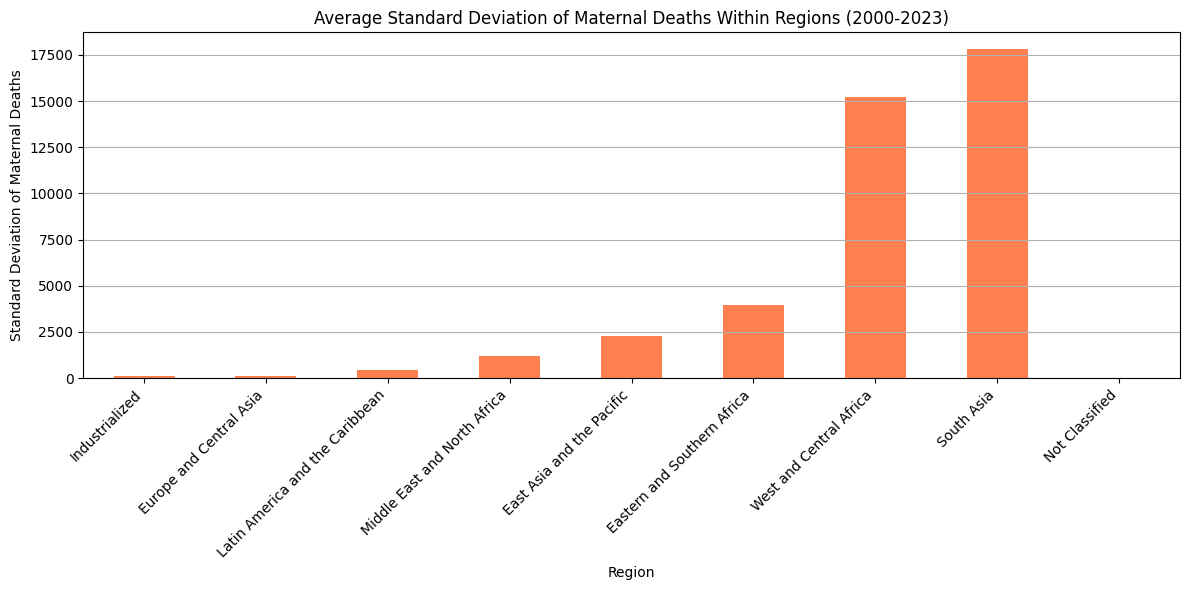

In [14]:
#Defining Variables
start_year = '2000'
end_year = '2023'

#Calculating percentage change in average maternal deaths per region (from 2000 to 2023)
percent_change = ((region_maternal_deaths[end_year] - region_maternal_deaths[start_year]) / region_maternal_deaths[start_year]) * 100
percent_change = percent_change.round(2)

#Outputs
print("Percentage change in average maternal deaths by region (2000 to 2023):")
print(percent_change.sort_values())

#Plotting
plt.figure(figsize=(12, 6))
percent_change.sort_values().plot(kind='bar', color='skyblue') #percentage change - maternal deaths
plt.title('Percentage Change in Average Maternal Deaths by Region (2000 to 2023)')
plt.ylabel('Percentage Change (%)')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#Calculating variability of country maternal deaths within each region per year
regions = maternal_deaths_country['UNICEF Programme Region'].unique()
variability_dict = {}

for region in regions: #looping through regions
    region_countries = maternal_deaths_country[maternal_deaths_country['UNICEF Programme Region'] == region] #specific countries
    std_devs = region_countries[years].apply(pd.to_numeric, errors='coerce').std(axis=0) #STD across countries overtime
    avg_std_dev = std_devs.mean() #Average STD
    variability_dict[region] = avg_std_dev

#adding to DF
variability_df = pd.Series(variability_dict).round(2).sort_values()

#Outputs
print("\nAverage standard deviation of maternal deaths within regions (variability across countries):")
print(variability_df)

#Plotting
plt.figure(figsize=(12, 6))
variability_df.plot(kind='bar', color='coral') #variability - maternal deaths
plt.title('Average Standard Deviation of Maternal Deaths Within Regions (2000-2023)')
plt.ylabel('Standard Deviation of Maternal Deaths')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


#Exploring Lifetime Risk of Maternal Death (LTR)

In [15]:
#Display Data Structure
ltr_country = pd.read_excel(file_path, sheet_name='LTR_country_level', skiprows=4)
ltr_country.head()

,ISO Code,Country,UNICEF Programme Region,UNICEF Reporting Region,UNICEF Sub-Reporting Region,2000,2001,2002,2003,2004,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AFG,Afghanistan,South Asia,South Asia,South Asia,10,11,11,12,13,...,24,25,26,29,31,33,32,31,37,40
1,ALB,Albania,Europe and Central Asia,Europe and Central Asia,Eastern Europe and Central Asia,3064,3482,3906,4024,4469,...,6589,7308,8190,9113,10067,10478,10703,5425,9461,10999
2,DZA,Algeria,Middle East and North Africa,Middle East and North Africa,Middle East and North Africa,337,374,429,428,464,...,401,406,411,420,443,465,364,465,590,633
3,AND,Andorra,Industrialized,Europe and Central Asia,Western Europe,5338,5430,5860,7162,7206,...,9771,9363,10165,9600,10736,11054,2469,6619,7014,10866
4,AGO,Angola,Eastern and Southern Africa,Sub-Saharan Africa,Eastern and Southern Africa,25,26,28,31,33,...,66,70,75,82,87,91,95,89,103,106


Global Average LTR Overtime

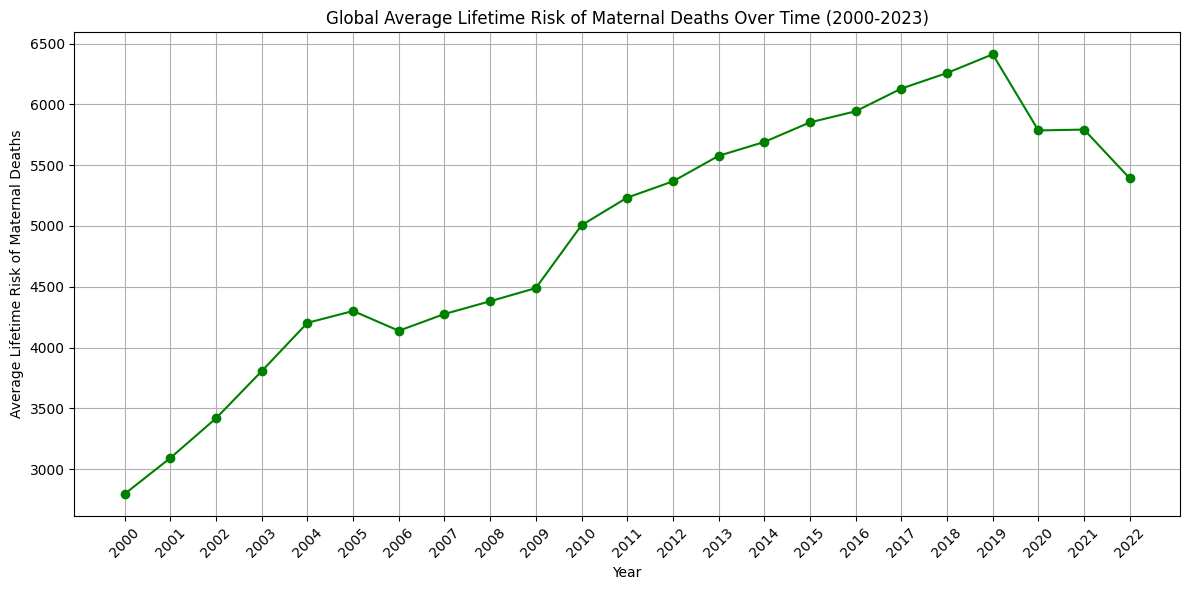

In [16]:
#Calculating average LTR
years = [str(year) for year in range(2000, 2023)]
global_ltr = ltr_country[years].mean()

#Plotting
plt.figure(figsize=(12, 6))
plt.plot(years, global_ltr.values, marker='o', color='green') #LTR
plt.title('Global Average Lifetime Risk of Maternal Deaths Over Time (2000-2023)')
plt.xlabel('Year')
plt.ylabel('Average Lifetime Risk of Maternal Deaths')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Average LTR by Region

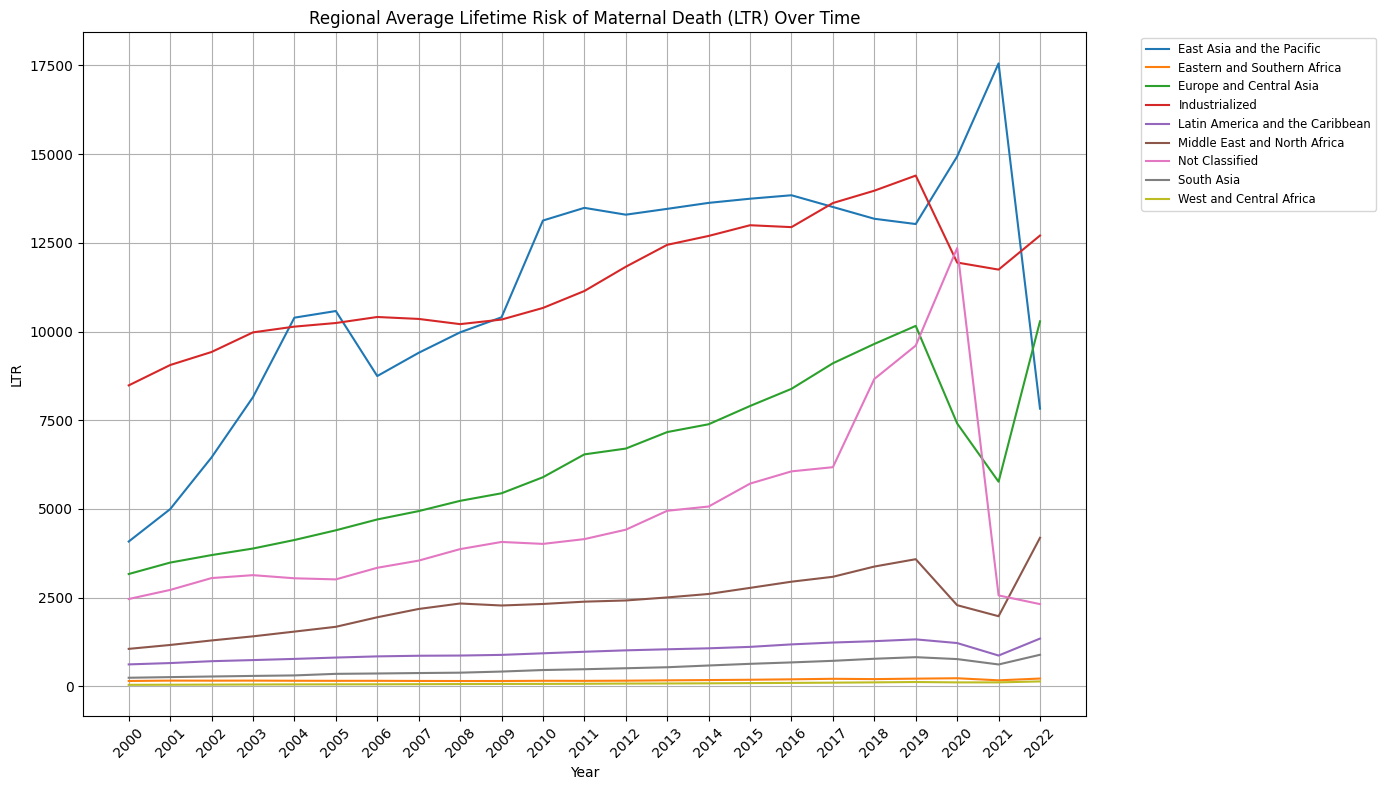

In [17]:
#grouped regions and calculated mean LTR per year
region_ltr = ltr_country.groupby('UNICEF Programme Region')[years].mean()

#Plotting
plt.figure(figsize=(14,8))
for region in region_ltr.index: #lopping through the regions overtime
    plt.plot(years, region_ltr.loc[region], label=region) #LTR
plt.title('Regional Average Lifetime Risk of Maternal Death (LTR) Over Time')
plt.xlabel('Year')
plt.ylabel('LTR')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

Specific Regions LTR Trends overlayed with Respective Countries

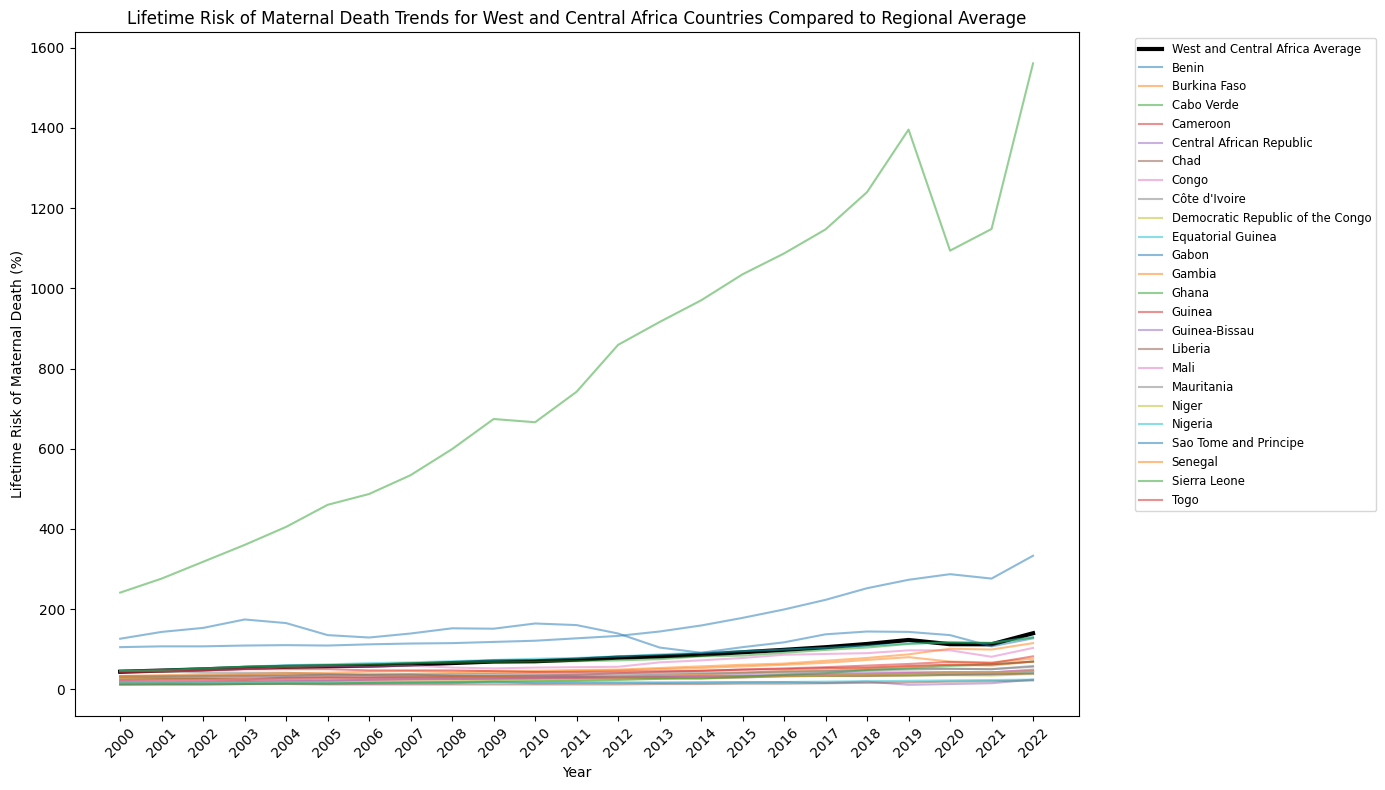

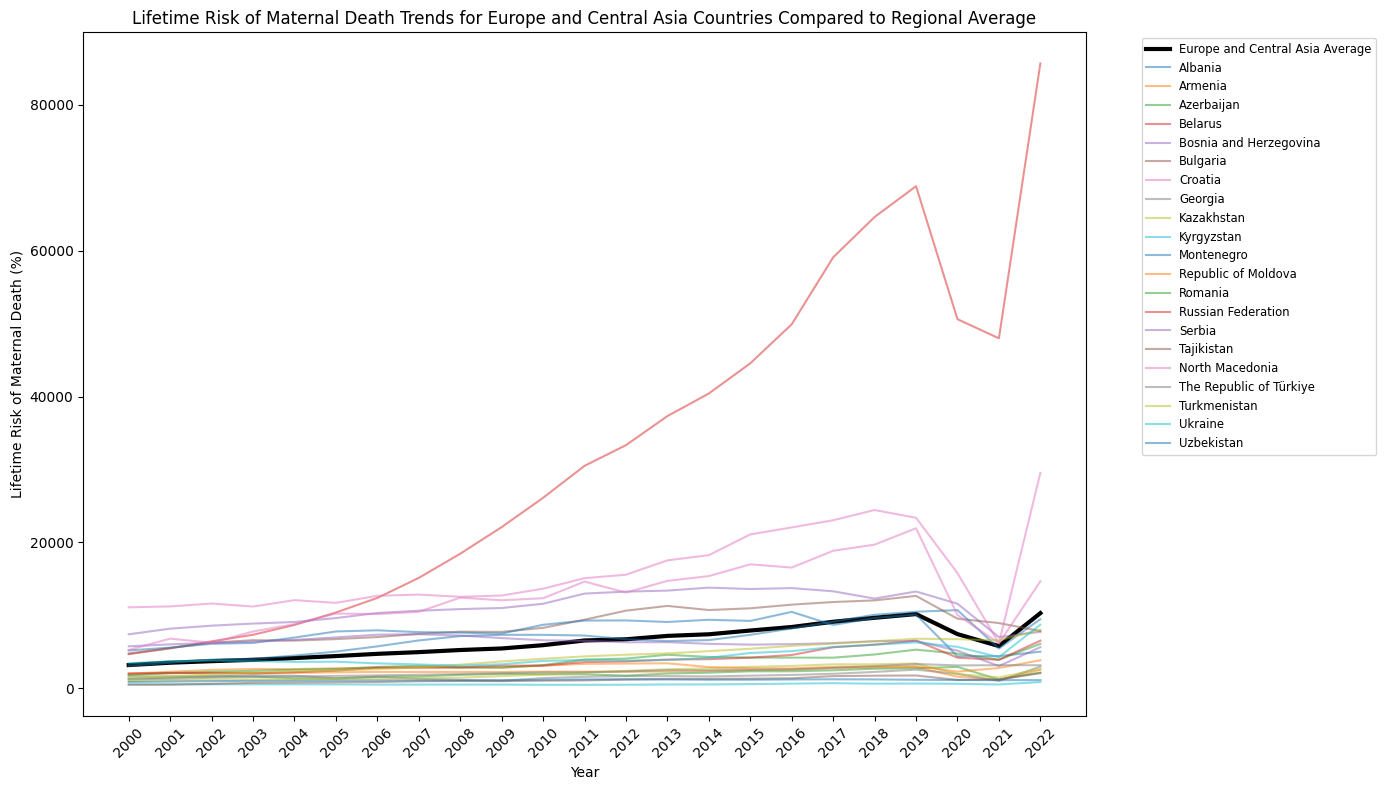

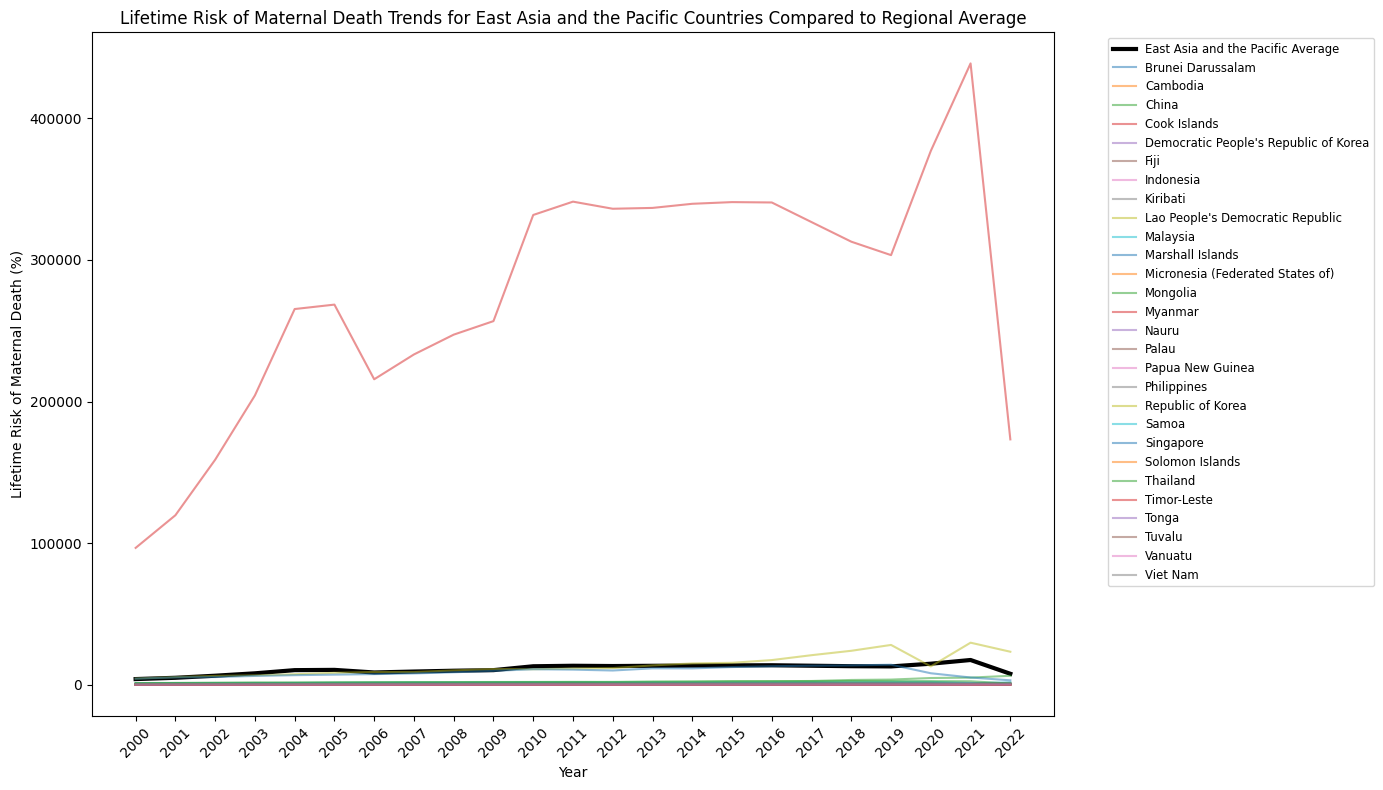

In [18]:
'''
Western and Central Africa
'''

#region
region = 'West and Central Africa'

#visualizing specific countries from that region
countries_in_region = ltr_country[ltr_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_ltr.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = ltr_country[ltr_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'Lifetime Risk of Maternal Death Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('Lifetime Risk of Maternal Death (%)')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

'''
Europe and Central Asia
'''

#region
region = 'Europe and Central Asia'

#visualizing specific countries from that region
countries_in_region = ltr_country[ltr_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_ltr.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = ltr_country[ltr_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'Lifetime Risk of Maternal Death Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('Lifetime Risk of Maternal Death (%)')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

'''
East Asia and the Pacific
'''

#region
region = 'East Asia and the Pacific'

#visualizing specific countries from that region
countries_in_region = ltr_country[ltr_country['UNICEF Programme Region'] == region]['Country'].tolist()

#Plotting
plt.figure(figsize=(14, 8))
plt.plot(years, region_ltr.loc[region], label=f'{region} Average', linewidth=3, color='black')  #regional average
for country in countries_in_region:
    country_data = ltr_country[ltr_country['Country'] == country][years].T
    plt.plot(years, country_data.values.flatten(), label=country, alpha=0.5)
plt.title(f'Lifetime Risk of Maternal Death Trends for {region} Countries Compared to Regional Average')
plt.xlabel('Year')
plt.ylabel('Lifetime Risk of Maternal Death (%)')
plt.xticks(rotation=45) #helping with the bunchiness of the x-axis
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()



Linear Regression on LTRto Visualize Annual trends

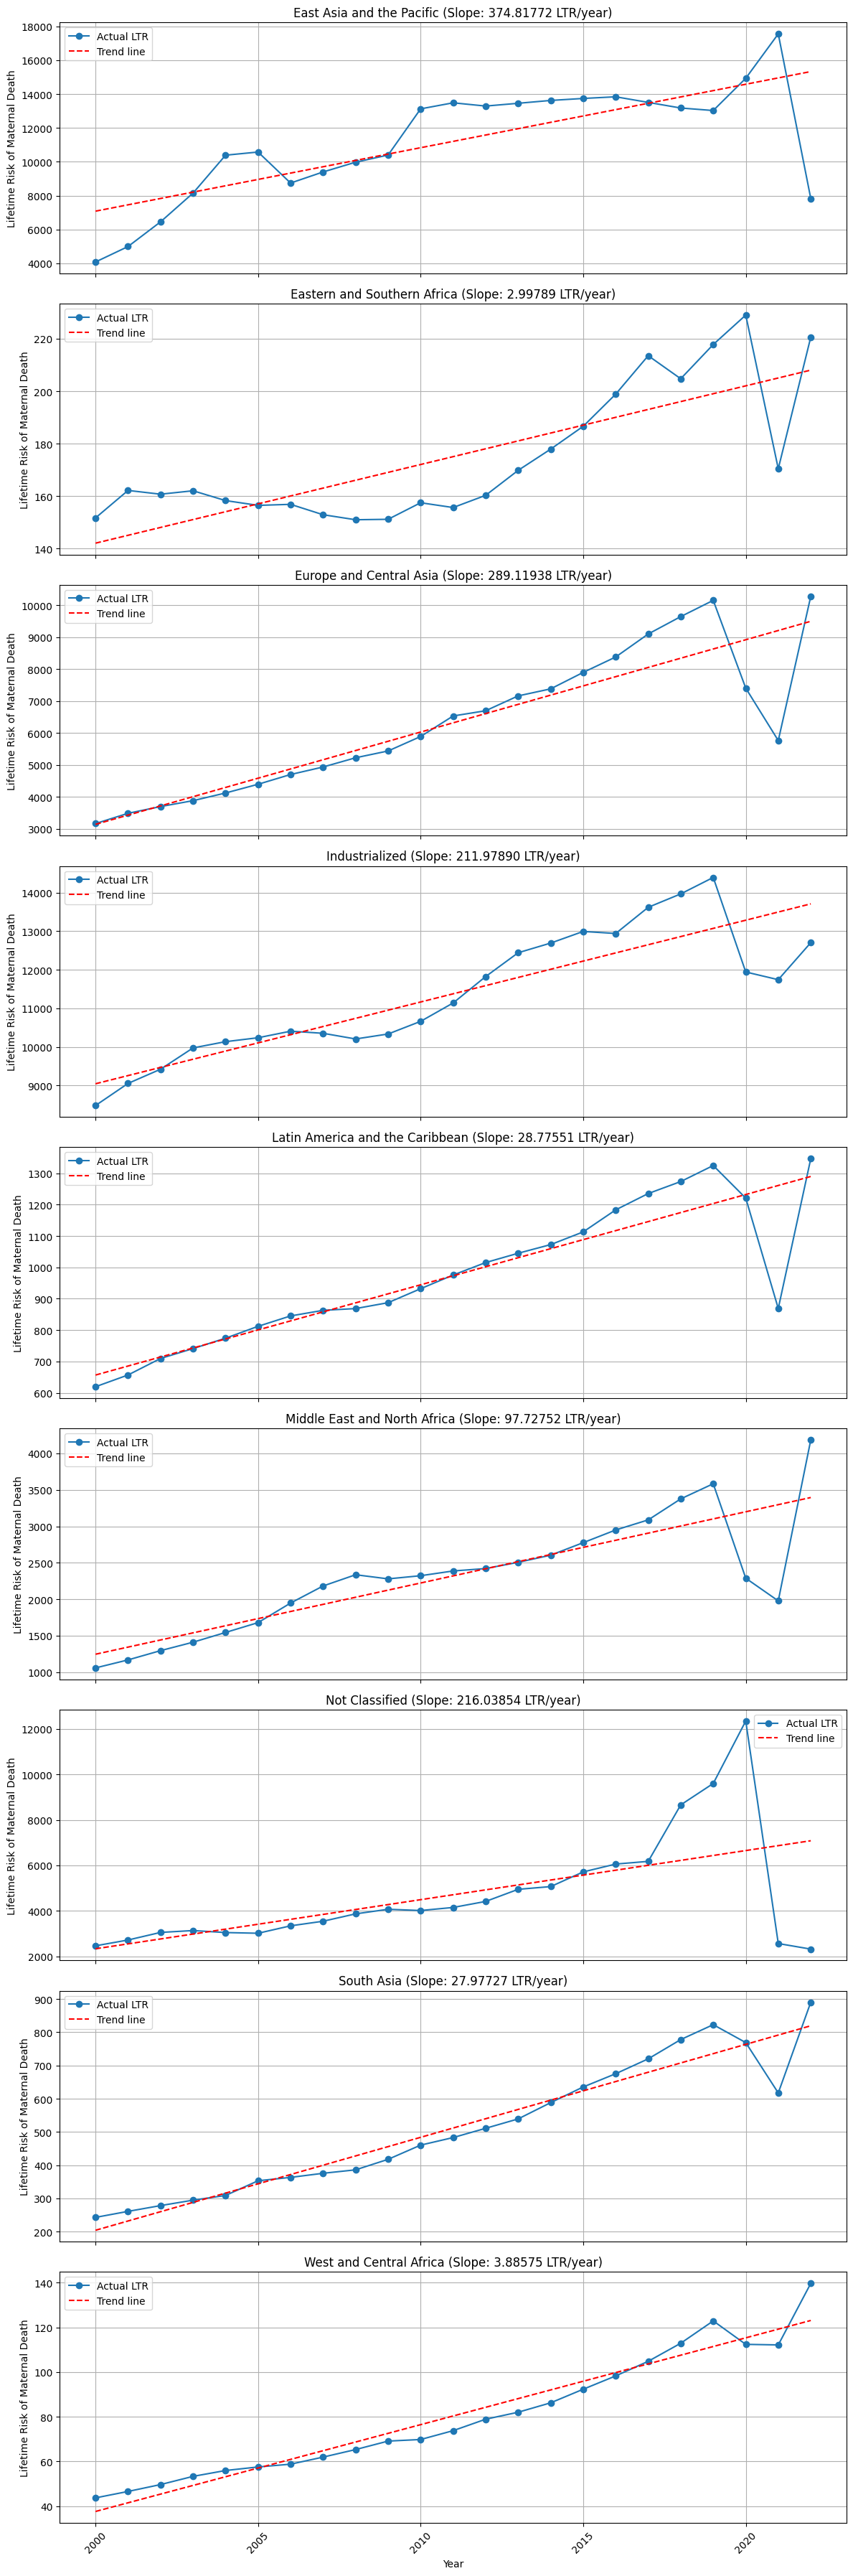

Yearly LTR trends by region (negative slope = decrease in lifetime risk):
                                 LTR Yearly Slope
Eastern and Southern Africa              2.997895
West and Central Africa                  3.885746
South Asia                              27.977273
Latin America and the Caribbean         28.775512
Middle East and North Africa            97.727520
Industrialized                         211.978902
Not Classified                         216.038538
Europe and Central Asia                289.119377
East Asia and the Pacific              374.817723


In [19]:
#Years
X = np.array([int(year) for year in years]).reshape(-1, 1)

#Storage for Slope (rate of change) for each region
region_slopes = {}

#One plot per region
num_regions = len(region_ltr.index)
fig, axs = plt.subplots(nrows=num_regions, ncols=1, figsize=(12, 4*num_regions), sharex=True)

#Ensuring if there is only 1 region, the axis will not be an array
if num_regions == 1:
    axs = [axs]

for i, region in enumerate(region_ltr.index): #looping through the regions
    y_vals_raw = region_ltr.loc[region, years].values.flatten() #flattening and extracting LTR values
    y_vals = pd.to_numeric(y_vals_raw, errors='coerce')
    mask = ~np.isnan(y_vals) #masking non-Nan values
    X_clean = X[mask]
    y_clean = y_vals[mask]

    if len(y_clean) > 1:
        model = LinearRegression() #linear regression
        model.fit(X_clean, y_clean) #fitting model
        slope = model.coef_[0]
        region_slopes[region] = slope

#Plotting
        axs[i].plot([int(y) for y in years], y_vals, marker='o', label='Actual LTR') #raw data points
        axs[i].plot([int(y) for y in years], model.predict(X), linestyle='--', color='red', label='Trend line') #regression line

        axs[i].set_title(f"{region} (Slope: {slope:.5f} LTR/year)")
        axs[i].set_ylabel('Lifetime Risk of Maternal Death') #LTR
        axs[i].grid(True)
        axs[i].legend()

plt.xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Adding slopes in storage to DF
region_slopes_df = pd.DataFrame.from_dict(region_slopes, orient='index', columns=['LTR Yearly Slope'])
region_slopes_df = region_slopes_df.sort_values('LTR Yearly Slope')

#Outputs
print("Yearly LTR trends by region (negative slope = decrease in lifetime risk):")
print(region_slopes_df)

Percentage and Variability within Regional Data - LTR

Percentage change in average LTR by region (2000 to 2023):
UNICEF Programme Region
Not Classified                      -5.85
Eastern and Southern Africa         45.43
Industrialized                      49.77
East Asia and the Pacific           91.74
Latin America and the Caribbean    117.35
West and Central Africa            219.85
Europe and Central Asia            224.86
South Asia                         266.65
Middle East and North Africa       296.03
dtype: float64


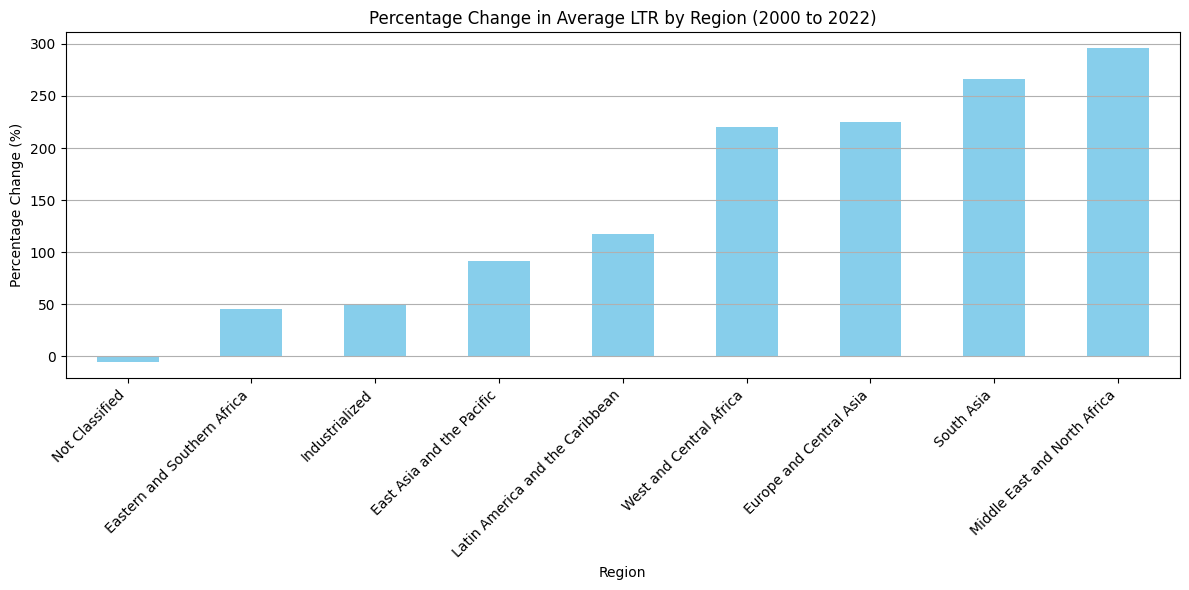


Average standard deviation of LTR within regions (variability across countries):
West and Central Africa              156.94020
Eastern and Southern Africa          326.14539
South Asia                           642.63076
Latin America and the Caribbean      841.89093
Middle East and North Africa        3657.86360
Industrialized                      6407.88451
Europe and Central Asia             7709.75945
East Asia and the Pacific          52149.78763
Not Classified                             NaN
dtype: float64


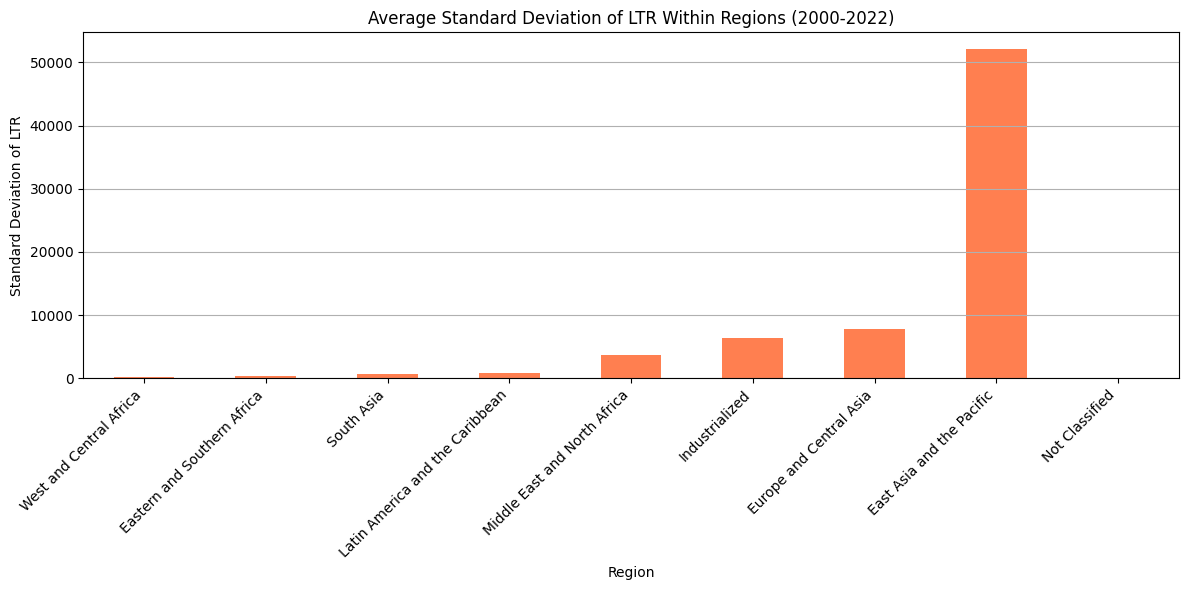

In [20]:
#Defining Variables
start_year = '2000'
end_year = '2022'

#Calculating percentage change in average LTR per region (from 2000 to 2023)
percent_change = ((region_ltr[end_year] - region_ltr[start_year]) / region_ltr[start_year]) * 100
percent_change = percent_change.round(2)

#Outputs
print("Percentage change in average LTR by region (2000 to 2023):")
print(percent_change.sort_values())

#Plotting
plt.figure(figsize=(12, 6))
percent_change.sort_values().plot(kind='bar', color='skyblue') #percentage change - LTR
plt.title('Percentage Change in Average LTR by Region (2000 to 2022)')
plt.ylabel('Percentage Change (%)')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Calculate variability (std deviation) of country LTR within each region per year
regions = ltr_country['UNICEF Programme Region'].unique()
variability_dict = {}

for region in regions: #looping through regions
    region_countries = ltr_country[ltr_country['UNICEF Programme Region'] == region] #specific countries
    std_devs = region_countries[years].apply(pd.to_numeric, errors='coerce').std(axis=0) #STD across countries overtime
    avg_std_dev = std_devs.mean() #average STD
    variability_dict[region] = avg_std_dev

#Adding varibaility to DF
variability_df = pd.Series(variability_dict).round(5).sort_values()

#Outputs
print("\nAverage standard deviation of LTR within regions (variability across countries):")
print(variability_df)

#Plotting
plt.figure(figsize=(12, 6))
variability_df.plot(kind='bar', color='coral') #variability - LTR
plt.title('Average Standard Deviation of LTR Within Regions (2000-2022)')
plt.ylabel('Standard Deviation of LTR')
plt.xlabel('Region')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


#Correlation and Regression through Variables

Correlation

In [21]:
#Putting Years into a list
years_list = [str(y) for y in range(2000, 2023)]

regions = region_mmr.index

#Storage for correlation data
corr_results = pd.DataFrame(index=regions, columns=['MMR-MaternalDeaths', 'MMR-LTR', 'MaternalDeaths-LTR'])

for region in regions: #looping over regions
    #Extraction of series for each variable
    mmr_series = pd.to_numeric(region_mmr.loc[region, years_list], errors='coerce')
    maternal_deaths_series = pd.to_numeric(region_maternal_deaths.loc[region, years_list], errors='coerce')
    ltr_series = pd.to_numeric(region_ltr.loc[region, years_list], errors='coerce')

    #Creation of new DF for correlation
    df = pd.DataFrame({
        'MMR': mmr_series,
        'MaternalDeaths': maternal_deaths_series,
        'LTR': ltr_series
    })

    #Dropping rows with NaNs
    df = df.dropna()

    if len(df) > 1:
        corr_results.loc[region, 'MMR-MaternalDeaths'] = df['MMR'].corr(df['MaternalDeaths'])
        corr_results.loc[region, 'MMR-LTR'] = df['MMR'].corr(df['LTR'])
        corr_results.loc[region, 'MaternalDeaths-LTR'] = df['MaternalDeaths'].corr(df['LTR'])

    #if there is not enough data
    else:
        corr_results.loc[region] = [np.nan, np.nan, np.nan]

#Outputs
print(corr_results.round(2))

                                MMR-MaternalDeaths   MMR-LTR  \
UNICEF Programme Region                                        
East Asia and the Pacific                 0.957934 -0.812331   
Eastern and Southern Africa               0.992658 -0.898641   
Europe and Central Asia                   0.958129 -0.940151   
Industrialized                            0.700724 -0.378363   
Latin America and the Caribbean           0.990903 -0.753958   
Middle East and North Africa               0.99693   -0.9206   
Not Classified                            0.444879 -0.496699   
South Asia                                0.997901  -0.93806   
West and Central Africa                  -0.581564 -0.979882   

                                MaternalDeaths-LTR  
UNICEF Programme Region                             
East Asia and the Pacific                -0.716687  
Eastern and Southern Africa              -0.902035  
Europe and Central Asia                  -0.971551  
Industrialized                

Visualization of Correlation

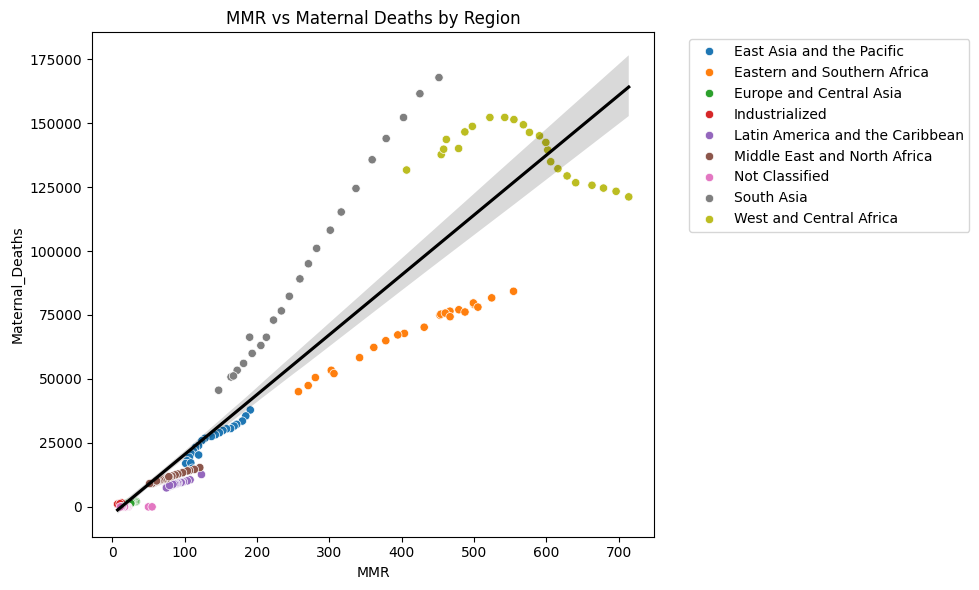

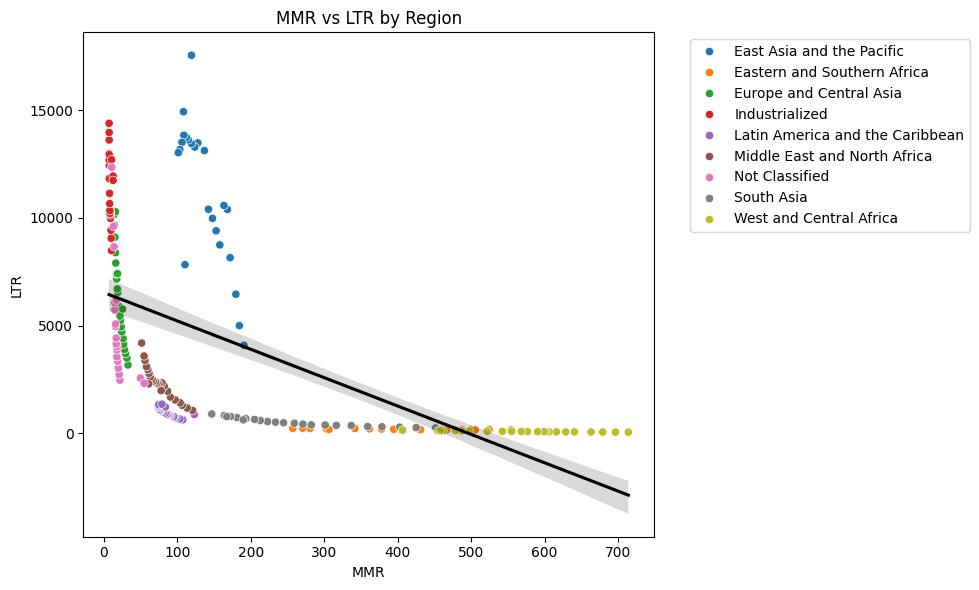

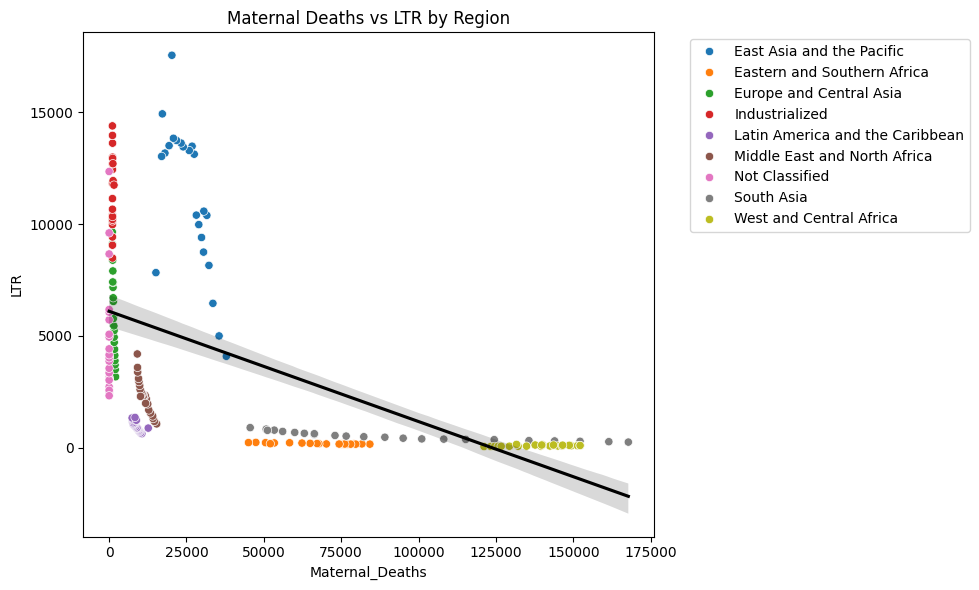

In [22]:
#imports
import seaborn as sns

#DF for correlation visualizations Prepare a long-format DataFrame for correlation plots
data_list = [] #empty list
for region in region_mmr.index: #looping through regions
    for year in years: #looping through years
        try:
            mmr_val = float(region_mmr.loc[region, year])
            md_val = float(region_maternal_deaths.loc[region, year])
            ltr_val = float(region_ltr.loc[region, year])

            #Ammending DF
            data_list.append({
                'Region': region,
                'Year': int(year),
                'MMR': mmr_val,
                'Maternal_Deaths': md_val,
                'LTR': ltr_val
            })
        except Exception:
            continue  #If data missing/invalid
#adding into DF
df_corr = pd.DataFrame(data_list)

#Plotting
def plot_scatter(x, y, title):
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df_corr, x=x, y=y, hue='Region')
    sns.regplot(data=df_corr, x=x, y=y, scatter=False, color='black')
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#Plotting
plot_scatter('MMR', 'Maternal_Deaths', 'MMR vs Maternal Deaths by Region') #MMR vs Maternal Deaths
plot_scatter('MMR', 'LTR', 'MMR vs LTR by Region')#MMR vs LTR
plot_scatter('Maternal_Deaths', 'LTR', 'Maternal Deaths vs LTR by Region') #Maternal Deaths vs LTR


Multiple Regression

In [23]:
#Imports
import statsmodels.api as sm

#Storage for multiple regression values
multiple_regression_results = {}

for region in df_corr['Region'].unique():
    df_region = df_corr[df_corr['Region'] == region]

    # Make sure there are enough data points
    if len(df_region) > 2:
        #Independent variables
        X = df_region[['LTR', 'Maternal_Deaths']]
        y = df_region['MMR']
        X = sm.add_constant(X) #Constant term
        model = sm.OLS(y, X).fit() #fitting to multiple linear regression

        #Adding to storage
        multiple_regression_results[region] = model.summary()
    else:
        multiple_regression_results[region] = None

#Outputs - per region
for region, summary in multiple_regression_results.items():
    print(f"Multiple Regression Results for {region}:")
    if summary:
        print(summary)
    else:
        print("Not enough data for regression.")
    print("\n" + "="*70 + "\n")


Multiple Regression Results for East Asia and the Pacific:
                            OLS Regression Results                            
Dep. Variable:                    MMR   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     190.7
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           9.43e-14
Time:                        15:04:36   Log-Likelihood:                -74.952
No. Observations:                  23   AIC:                             155.9
Df Residuals:                      20   BIC:                             159.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------